# Lab Practical 4: CNN Architectures for Imbalanced Image Classification

## Overview

| # | Dataset | Classes | Imbalance Strategy |
|---|---------|---------|-------------------|
| 1 | **CIFAR-10 (Imbalanced)** | 10 (airplane, automobile, bird, ...) | Long-tailed distribution, 100:1 ratio |
| 2 | **Flower Recognition** | 5 (daisy, dandelion, roses, sunflowers, tulips) | Custom sampling: 100:500:200:50:150 |

### Table of Contents
1. **Problem Statement 1** — Architecture Design Focus
2. **Problem Statement 2** — Imbalanced Dataset Handling
3. **Problem Statement 3** — Comparative Architecture Analysis (ResNet18 vs MobileNetV2)
4. **Problem Statement 4** — Loss Function & Optimization Challenge
5. **Problem Statement 5** — Feature Representation & Visualization
6. **Problem Statement 6** — Generalization & Transfer Learning Test
7. **Problem Statement 7** — Error Analysis & Improvement Proposals

In [12]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import torchvision
import torchvision.transforms as transforms
import torchvision.models as models
from torch.utils.data import DataLoader, Dataset, WeightedRandomSampler, Subset
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (confusion_matrix, classification_report, f1_score,
                             accuracy_score, precision_score, recall_score,
                             roc_auc_score, roc_curve, auc, precision_recall_curve,
                             balanced_accuracy_score, average_precision_score)
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA
from sklearn.preprocessing import label_binarize
import os, sys, random, time, copy, warnings
from tqdm import tqdm
from collections import Counter, OrderedDict
from torchvision.datasets.utils import download_and_extract_archive

warnings.filterwarnings('ignore')

# ===== Reproducibility =====
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(42)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')
if device.type == 'cuda':
    print(f'GPU: {torch.cuda.get_device_name(0)}')

NUM_WORKERS = 0  
NUM_EPOCHS = 10

Using device: cuda
GPU: NVIDIA GeForce RTX 3050 Laptop GPU


---
## Dataset Preparation

### Dataset 1: CIFAR-10 (Imbalanced)
We create a **long-tailed distribution** from the standard CIFAR-10 training set. With an imbalance ratio of 0.01 (100:1):
- Class 0 (airplane): ~5000 samples (majority)
- Class 9 (truck): ~50 samples (minority)
- Intermediate classes follow exponential decay

### Dataset 2: Flower Recognition (Imbalanced)
The Flower Photos dataset has 5 classes. We create artificial imbalance:
- daisy: 100, dandelion: 500, roses: 200, sunflowers: 50, tulips: 150

In [3]:
class ImbalancedCIFAR10(torchvision.datasets.CIFAR10):
    '''CIFAR-10 with long-tailed imbalanced class distribution.'''

    def __init__(self, root, train=True, transform=None, target_transform=None,
                 download=False, imbalance_ratio=0.01):
        super().__init__(root, train, transform, target_transform, download)
        if train:
            self.imbalance_ratio = imbalance_ratio
            self.num_cls = 10
            self._create_imbalanced_data()

    def _create_imbalanced_data(self):
        img_max = len(self.data) / self.num_cls  # 5000 per class originally
        img_num_per_cls = []
        for cls_idx in range(self.num_cls):
            num = img_max * (self.imbalance_ratio ** (cls_idx / (self.num_cls - 1.0)))
            img_num_per_cls.append(int(num))

        new_data, new_targets = [], []
        targets_np = np.array(self.targets)
        self.cls_num_list = img_num_per_cls

        for cls_id, num_samples in enumerate(img_num_per_cls):
            idx = np.where(targets_np == cls_id)[0]
            np.random.shuffle(idx)
            selected = idx[:num_samples]
            new_data.append(self.data[selected])
            new_targets.extend([cls_id] * num_samples)

        self.data = np.vstack(new_data)
        self.targets = new_targets
        print(f'Imbalanced CIFAR-10 distribution: {img_num_per_cls}')
        print(f'Total training samples: {len(self.targets)}')

    def get_cls_num_list(self):
        return self.cls_num_list

In [4]:
class ImbalancedFlowerDataset(Dataset):
    '''Wrapper to create an imbalanced version of the Flower dataset.'''

    def __init__(self, dataset, class_samples=None):
        '''
        Args:
            dataset: ImageFolder dataset
            class_samples: dict mapping class_idx -> max_samples
        '''
        self.dataset = dataset
        self.classes = dataset.classes
        self.class_to_idx = dataset.class_to_idx

        if class_samples is not None:
            self._create_imbalanced_indices(class_samples)
        else:
            self.indices = list(range(len(dataset)))
            self.cls_num_list = list(Counter(dataset.targets).values())

    def _create_imbalanced_indices(self, class_samples):
        targets_np = np.array(self.dataset.targets)
        self.indices = []
        self.cls_num_list = []
        for cls_id in sorted(class_samples.keys()):
            available = np.where(targets_np == cls_id)[0]
            np.random.shuffle(available)
            n = min(class_samples[cls_id], len(available))
            self.indices.extend(available[:n].tolist())
            self.cls_num_list.append(n)
        print(f'Imbalanced Flower distribution: {self.cls_num_list}')
        print(f'Classes: {self.classes}')
        print(f'Total samples: {len(self.indices)}')

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, idx):
        return self.dataset[self.indices[idx]]

    def get_cls_num_list(self):
        return self.cls_num_list

    @property
    def targets(self):
        return [self.dataset.targets[i] for i in self.indices]


def get_flower_dataset(root='./data', transform=None):
    '''Download and load the Flower Photos dataset (5 classes).'''
    url = 'http://download.tensorflow.org/example_images/flower_photos.tgz'
    dataset_path = os.path.join(root, 'flower_photos')

    if not os.path.exists(dataset_path):
        print('Downloading Flower Photos dataset...')
        try:
            download_and_extract_archive(url, root, filename='flower_photos.tgz')
        except Exception as e:
            print(f'Download failed: {e}')
            print('Please download manually from:', url)
            return None

    # Remove LICENSE file if present (confuses ImageFolder)
    license_path = os.path.join(dataset_path, 'LICENSE.txt')
    if os.path.exists(license_path):
        os.remove(license_path)

    dataset = torchvision.datasets.ImageFolder(root=dataset_path, transform=transform)
    print(f'Flower dataset loaded: {len(dataset)} images, {len(dataset.classes)} classes')
    print(f'Classes: {dataset.classes}')
    return dataset

---
## Loss Functions

We implement several loss functions for experimentation in Problem Statement 4:

| Loss Function | Key Idea |
|--------------|----------|
| **CrossEntropy** | Standard baseline |
| **Weighted CrossEntropy** | Inverse class frequency weighting |
| **Focal Loss** | Down-weights easy examples, focuses on hard/minority samples |
| **Class-Balanced Loss** | Weights by effective number of samples |
| **Label Smoothing CE** | Regularization to prevent overconfident predictions |

In [5]:
class FocalLoss(nn.Module):
    '''Focal Loss: down-weights easy examples to focus on hard ones.
    FL(pt) = -alpha * (1-pt)^gamma * log(pt)
    '''
    def __init__(self, alpha=1.0, gamma=2.0, weight=None, reduction='mean'):
        super().__init__()
        self.alpha = alpha
        self.gamma = gamma
        self.weight = weight
        self.reduction = reduction

    def forward(self, inputs, targets):
        ce_loss = F.cross_entropy(inputs, targets, weight=self.weight, reduction='none')
        pt = torch.exp(-ce_loss)
        focal_loss = self.alpha * (1 - pt) ** self.gamma * ce_loss
        if self.reduction == 'mean':
            return focal_loss.mean()
        elif self.reduction == 'sum':
            return focal_loss.sum()
        return focal_loss


class ClassBalancedLoss(nn.Module):
    '''Class-Balanced Loss using effective number of samples.
    Effective number = (1 - beta^n) / (1 - beta), where n = samples per class.
    '''
    def __init__(self, samples_per_cls, num_classes, beta=0.9999, gamma=2.0):
        super().__init__()
        effective_num = 1.0 - np.power(beta, np.array(samples_per_cls))
        weights = (1.0 - beta) / effective_num
        weights = weights / np.sum(weights) * num_classes
        self.weights = torch.tensor(weights, dtype=torch.float32)
        self.gamma = gamma

    def forward(self, inputs, targets):
        w = self.weights.to(inputs.device)
        return FocalLoss(gamma=self.gamma, weight=w)(inputs, targets)


class LabelSmoothingCE(nn.Module):
    '''Cross-Entropy with Label Smoothing for regularization.'''
    def __init__(self, num_classes=10, smoothing=0.1):
        super().__init__()
        self.num_classes = num_classes
        self.smoothing = smoothing
        self.confidence = 1.0 - smoothing

    def forward(self, inputs, targets):
        logprobs = F.log_softmax(inputs, dim=-1)
        nll_loss = -logprobs.gather(dim=-1, index=targets.unsqueeze(1)).squeeze(1)
        smooth_loss = -logprobs.mean(dim=-1)
        loss = self.confidence * nll_loss + self.smoothing * smooth_loss
        return loss.mean()

In [ ]:
# ===================================================================
# Training, Evaluation, and Visualization Utilities
# ===================================================================

def train_model(model, train_loader, val_loader, criterion, optimizer,
                num_epochs=5, scheduler=None, name='Model', verbose=True):
    '''Train model and return training history. Saves best model weights.'''
    history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': [], 'val_f1': []}
    best_acc = 0.0
    best_model_wts = copy.deepcopy(model.state_dict())

    for epoch in range(num_epochs):
        model.train()
        running_loss, correct, total = 0.0, 0, 0

        pbar = tqdm(train_loader, desc=f'{name} [{epoch+1}/{num_epochs}]', leave=False)
        for inputs, labels in pbar:
            inputs, labels = inputs.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item()
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()

        if scheduler is not None:
            scheduler.step()

        train_loss = running_loss / len(train_loader)
        train_acc = 100. * correct / total

        # Validation
        val_loss, val_acc, y_true, y_pred, _ = evaluate_model(model, val_loader, criterion)
        val_f1 = f1_score(y_true, y_pred, average='macro') * 100

        history['train_loss'].append(train_loss)
        history['train_acc'].append(train_acc)
        history['val_loss'].append(val_loss)
        history['val_acc'].append(val_acc)
        history['val_f1'].append(val_f1)

        if val_acc > best_acc:
            best_acc = val_acc
            best_model_wts = copy.deepcopy(model.state_dict())

        if verbose:
            print(f'  Epoch {epoch+1}: TrainLoss={train_loss:.4f} TrainAcc={train_acc:.1f}% '
                  f'ValLoss={val_loss:.4f} ValAcc={val_acc:.1f}% ValF1={val_f1:.1f}%')

    model.load_state_dict(best_model_wts)
    return history


def evaluate_model(model, loader, criterion=None):
    '''Evaluate model. Returns (loss, accuracy, true_labels, predictions, probabilities).'''
    model.eval()
    running_loss, correct, total = 0.0, 0, 0
    all_labels, all_preds, all_probs = [], [], []

    with torch.no_grad():
        for inputs, labels in loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            if criterion:
                running_loss += criterion(outputs, labels).item()

            probs = torch.softmax(outputs, dim=1)
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()

            all_labels.extend(labels.cpu().numpy())
            all_preds.extend(predicted.cpu().numpy())
            all_probs.append(probs.cpu().numpy())

    loss = running_loss / len(loader) if criterion else 0
    acc = 100. * correct / total
    all_probs = np.vstack(all_probs) if all_probs else np.array([])
    return loss, acc, np.array(all_labels), np.array(all_preds), all_probs


def get_all_metrics(y_true, y_pred, y_prob, class_names, title=''):
    '''Compute and print comprehensive metrics.'''
    acc = accuracy_score(y_true, y_pred) * 100
    bal_acc = balanced_accuracy_score(y_true, y_pred) * 100
    f1_mac = f1_score(y_true, y_pred, average='macro') * 100
    f1_mic = f1_score(y_true, y_pred, average='micro') * 100
    prec = precision_score(y_true, y_pred, average='macro', zero_division=0) * 100
    rec = recall_score(y_true, y_pred, average='macro', zero_division=0) * 100

    cm = confusion_matrix(y_true, y_pred)
    per_class_recall = cm.diagonal() / cm.sum(axis=1).clip(min=1)
    g_mean = np.prod(per_class_recall) ** (1.0 / len(per_class_recall)) * 100

    metrics = OrderedDict([
        ('Accuracy', acc), ('Balanced Accuracy', bal_acc),
        ('Macro F1', f1_mac), ('Micro F1', f1_mic),
        ('Macro Precision', prec), ('Macro Recall', rec), ('G-Mean', g_mean)
    ])

    if title:
        print(f'\n{"="*50}')
        print(f'  {title}')
        print(f'{"="*50}')
    for k, v in metrics.items():
        print(f'  {k:20s}: {v:.2f}%')
    return metrics


def plot_training_history(history, title='Training History'):
    fig, axes = plt.subplots(1, 3, figsize=(18, 4))
    axes[0].plot(history['train_loss'], 'b-o', label='Train', markersize=4)
    axes[0].plot(history['val_loss'], 'r-o', label='Val', markersize=4)
    axes[0].set_title('Loss'); axes[0].legend(); axes[0].set_xlabel('Epoch'); axes[0].grid(True, alpha=0.3)

    axes[1].plot(history['train_acc'], 'b-o', label='Train', markersize=4)
    axes[1].plot(history['val_acc'], 'r-o', label='Val', markersize=4)
    axes[1].set_title('Accuracy (%)'); axes[1].legend(); axes[1].set_xlabel('Epoch'); axes[1].grid(True, alpha=0.3)

    axes[2].plot(history['val_f1'], 'g-o', label='Val Macro F1', markersize=4)
    axes[2].set_title('Val Macro F1 (%)'); axes[2].legend(); axes[2].set_xlabel('Epoch'); axes[2].grid(True, alpha=0.3)

    plt.suptitle(title, fontsize=14, fontweight='bold')
    plt.tight_layout(); plt.show()


def plot_confusion_matrix(y_true, y_pred, classes, title='Confusion Matrix'):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=classes, yticklabels=classes)
    plt.title(title, fontsize=13)
    plt.ylabel('True Label'); plt.xlabel('Predicted Label')
    plt.tight_layout(); plt.show()


def count_parameters(model):
    '''Count trainable parameters.'''
    return sum(p.numel() for p in model.parameters() if p.requires_grad)


def measure_inference_time(model, input_size=(1, 3, 32, 32), n_runs=100):
    '''Measure average inference time in milliseconds.'''
    model.eval()
    dummy = torch.randn(*input_size).to(device)
    # Warmup
    with torch.no_grad():
        for _ in range(10):
            _ = model(dummy)
    if device.type == 'cuda':
        torch.cuda.synchronize()
    start = time.time()
    with torch.no_grad():
        for _ in range(n_runs):
            _ = model(dummy)
    if device.type == 'cuda':
        torch.cuda.synchronize()
    elapsed = (time.time() - start) / n_runs * 1000  # ms
    return elapsed

---
## Data Loading and Visualization

In [7]:
# ===== Transforms =====
transform_cifar_train = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010)),
])
transform_cifar_test = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010)),
])

transform_flower_train = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.RandomCrop(64, padding=8),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
])
transform_flower_test = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
])

# ===== Load CIFAR-10 (Imbalanced) =====
print('=' * 60)
print('Loading CIFAR-10 (Imbalanced)...')
print('=' * 60)
set_seed(42)
trainset_cifar = ImbalancedCIFAR10(root='./data', train=True, download=True,
                                    transform=transform_cifar_train, imbalance_ratio=0.01)
testset_cifar = torchvision.datasets.CIFAR10(root='./data', train=False,
                                              download=True, transform=transform_cifar_test)

trainloader_cifar = DataLoader(trainset_cifar, batch_size=64, shuffle=True, num_workers=NUM_WORKERS)
testloader_cifar = DataLoader(testset_cifar, batch_size=64, shuffle=False, num_workers=NUM_WORKERS)

CIFAR_CLASSES = ('plane', 'car', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck')
cifar_cls_num = trainset_cifar.get_cls_num_list()
print(f'Imbalance ratio: {max(cifar_cls_num)/min(cifar_cls_num):.1f}:1')

Loading CIFAR-10 (Imbalanced)...
Imbalanced CIFAR-10 distribution: [5000, 2997, 1796, 1077, 645, 387, 232, 139, 83, 50]
Total training samples: 12406
Imbalance ratio: 100.0:1


In [8]:
# ===== Load Flower Photos (Imbalanced) =====
print('=' * 60)
print('Loading Flower Photos (Imbalanced)...')
print('=' * 60)
set_seed(42)
FLOWER_CLASSES = None
flower_cls_num = None

flower_full_train = get_flower_dataset(root='./data', transform=transform_flower_train)

if flower_full_train is not None:
    FLOWER_CLASSES = flower_full_train.classes
    # Create imbalanced version: daisy=100, dandelion=500, roses=200, sunflowers=50, tulips=150
    flower_imbalance = {0: 100, 1: 500, 2: 200, 3: 50, 4: 150}
    trainset_flower = ImbalancedFlowerDataset(flower_full_train, class_samples=flower_imbalance)
    flower_cls_num = trainset_flower.get_cls_num_list()

    # Test set (20% split from full dataset with test transforms)
    flower_full_test = get_flower_dataset(root='./data', transform=transform_flower_test)
    total_flower = len(flower_full_test)
    all_indices = list(range(total_flower))
    np.random.shuffle(all_indices)
    test_size = int(0.2 * total_flower)
    testset_flower = Subset(flower_full_test, all_indices[:test_size])

    trainloader_flower = DataLoader(trainset_flower, batch_size=32, shuffle=True, num_workers=NUM_WORKERS)
    testloader_flower = DataLoader(testset_flower, batch_size=32, shuffle=False, num_workers=NUM_WORKERS)
    print(f'Flower train: {len(trainset_flower)}, test: {len(testset_flower)}')
    print(f'Imbalance ratio: {max(flower_cls_num)/min(flower_cls_num):.1f}:1')
else:
    print('WARNING: Flower dataset unavailable. Flower-specific experiments will be skipped.')

Loading Flower Photos (Imbalanced)...


100%|██████████| 229M/229M [03:18<00:00, 1.15MB/s] 


Flower dataset loaded: 3670 images, 5 classes
Classes: ['daisy', 'dandelion', 'roses', 'sunflowers', 'tulips']
Imbalanced Flower distribution: [100, 500, 200, 50, 150]
Classes: ['daisy', 'dandelion', 'roses', 'sunflowers', 'tulips']
Total samples: 1000
Flower dataset loaded: 3670 images, 5 classes
Classes: ['daisy', 'dandelion', 'roses', 'sunflowers', 'tulips']
Flower train: 1000, test: 734
Imbalance ratio: 10.0:1


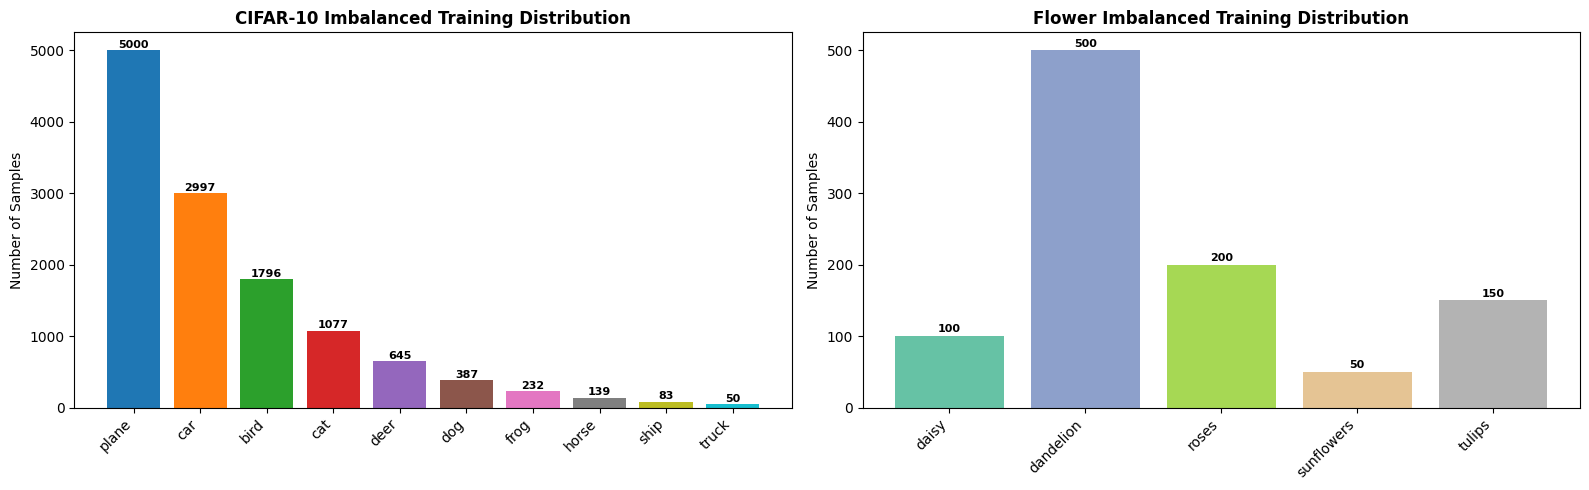

In [13]:
# ===== Visualize Class Distributions =====
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

colors_cifar = plt.cm.tab10(np.linspace(0, 1, 10))
bars1 = axes[0].bar(range(10), cifar_cls_num, color=colors_cifar)
axes[0].set_xticks(range(10))
axes[0].set_xticklabels(CIFAR_CLASSES, rotation=45, ha='right')
axes[0].set_title('CIFAR-10 Imbalanced Training Distribution', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Number of Samples')
for i, v in enumerate(cifar_cls_num):
    axes[0].text(i, v + 30, str(v), ha='center', fontsize=8, fontweight='bold')

if flower_cls_num is not None:
    colors_flower = plt.cm.Set2(np.linspace(0, 1, 5))
    bars2 = axes[1].bar(range(5), flower_cls_num, color=colors_flower)
    axes[1].set_xticks(range(5))
    axes[1].set_xticklabels(FLOWER_CLASSES, rotation=45, ha='right')
    axes[1].set_title('Flower Imbalanced Training Distribution', fontsize=12, fontweight='bold')
    axes[1].set_ylabel('Number of Samples')
    for i, v in enumerate(flower_cls_num):
        axes[1].text(i, v + 5, str(v), ha='center', fontsize=8, fontweight='bold')
else:
    axes[1].text(0.5, 0.5, 'Flower dataset not available', ha='center', va='center', fontsize=14)

plt.tight_layout()
plt.show()

---
# Problem Statement 1: Architecture Design Focus

> **Objective**: Design a custom CNN architecture and modify a standard model for multi-class classification on imbalanced datasets.

## Architecture Choices

### 1. Custom CNN (Designed from Scratch)
- **4 convolutional blocks** with increasing filter sizes: 32 → 64 → 128 → 256
- **Kernel size 3×3** throughout — small receptive fields capture fine-grained features
- **BatchNorm** after every conv layer for training stability
- **Dropout2D (0.1–0.3)** and FC Dropout (0.5) to prevent overfitting on majority classes
- **Global Average Pooling** to reduce parameter count
- **ReLU** activations — simple, effective, avoids vanishing gradients
- **L2 regularization** via weight_decay in optimizer

### 2. Modified ResNet18 (Transfer Learning)
- **Pre-trained on ImageNet** — leverages rich feature representations
- **Skip connections** help gradient flow in deeper networks
- **Modified final FC** with Dropout for the target number of classes
- Already includes BatchNorm in residual blocks

### Justification
- CIFAR-10 images are only 32×32, so very deep architectures may overfit. ResNet18 is a good balance.
- Transfer learning compensates for the small number of minority class samples.
- Heavy regularization is critical when minority classes have very few training samples.

In [14]:
class CustomCNN(nn.Module):
    '''
    Custom CNN for imbalanced classification.
    4 Conv blocks + Global Average Pooling + 2 FC layers.
    Heavy regularization: BatchNorm, Dropout2D, FC Dropout, L2 (via optimizer).
    '''
    def __init__(self, num_classes=10, dropout_rate=0.5):
        super().__init__()
        self.features = nn.Sequential(
            # Block 1: 32x32 -> 16x16
            nn.Conv2d(3, 32, 3, padding=1), nn.BatchNorm2d(32), nn.ReLU(inplace=True),
            nn.Conv2d(32, 32, 3, padding=1), nn.BatchNorm2d(32), nn.ReLU(inplace=True),
            nn.MaxPool2d(2), nn.Dropout2d(0.1),
            # Block 2: 16x16 -> 8x8
            nn.Conv2d(32, 64, 3, padding=1), nn.BatchNorm2d(64), nn.ReLU(inplace=True),
            nn.Conv2d(64, 64, 3, padding=1), nn.BatchNorm2d(64), nn.ReLU(inplace=True),
            nn.MaxPool2d(2), nn.Dropout2d(0.2),
            # Block 3: 8x8 -> 4x4
            nn.Conv2d(64, 128, 3, padding=1), nn.BatchNorm2d(128), nn.ReLU(inplace=True),
            nn.Conv2d(128, 128, 3, padding=1), nn.BatchNorm2d(128), nn.ReLU(inplace=True),
            nn.MaxPool2d(2), nn.Dropout2d(0.25),
            # Block 4: 4x4 -> 2x2
            nn.Conv2d(128, 256, 3, padding=1), nn.BatchNorm2d(256), nn.ReLU(inplace=True),
            nn.Conv2d(256, 256, 3, padding=1), nn.BatchNorm2d(256), nn.ReLU(inplace=True),
            nn.MaxPool2d(2), nn.Dropout2d(0.3),
        )
        self.classifier = nn.Sequential(
            nn.AdaptiveAvgPool2d(1),   # Global Average Pooling
            nn.Flatten(),
            nn.Linear(256, 128), nn.ReLU(inplace=True), nn.Dropout(dropout_rate),
            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        return self.classifier(self.features(x))


def get_resnet18(num_classes=10, pretrained=True, dropout=0.3):
    '''Modified ResNet18 with Dropout before final FC layer.'''
    model = models.resnet18(pretrained=pretrained)
    num_ftrs = model.fc.in_features
    model.fc = nn.Sequential(
        nn.Dropout(dropout),
        nn.Linear(num_ftrs, num_classes)
    )
    return model


def get_mobilenetv2(num_classes=10, pretrained=True, dropout=0.2):
    '''Modified MobileNetV2 for classification.'''
    model = models.mobilenet_v2(pretrained=pretrained)
    num_ftrs = model.classifier[1].in_features
    model.classifier = nn.Sequential(
        nn.Dropout(dropout),
        nn.Linear(num_ftrs, num_classes)
    )
    return model


# ===== Print Architecture Summaries =====
tmp_custom = CustomCNN(num_classes=10)
tmp_resnet = get_resnet18(num_classes=10)
tmp_mobile = get_mobilenetv2(num_classes=10)

print(f'Custom CNN    — Parameters: {count_parameters(tmp_custom):>10,}')
print(f'ResNet18      — Parameters: {count_parameters(tmp_resnet):>10,}')
print(f'MobileNetV2   — Parameters: {count_parameters(tmp_mobile):>10,}')
del tmp_custom, tmp_resnet, tmp_mobile

Custom CNN    — Parameters:  1,208,362
ResNet18      — Parameters: 11,181,642
MobileNetV2   — Parameters:  2,236,682



PS1: Training Custom CNN (CrossEntropy, no imbalance handling)


  Epoch 1: TrainLoss=1.3095 TrainAcc=55.5% ValLoss=2.7752 ValAcc=22.4% ValF1=12.1%


  Epoch 2: TrainLoss=1.1024 TrainAcc=62.7% ValLoss=3.0474 ValAcc=24.4% ValF1=13.1%


  Epoch 3: TrainLoss=1.0397 TrainAcc=65.4% ValLoss=2.4229 ValAcc=27.2% ValF1=15.5%


  Epoch 4: TrainLoss=0.9801 TrainAcc=67.8% ValLoss=2.5498 ValAcc=29.4% ValF1=18.8%


...

  Epoch 6: TrainLoss=0.5578 TrainAcc=82.2% ValLoss=2.0268 ValAcc=47.7% ValF1=42.1%


  Epoch 7: TrainLoss=0.5114 TrainAcc=83.2% ValLoss=1.9828 ValAcc=47.4% ValF1=42.1%


  Epoch 8: TrainLoss=0.4871 TrainAcc=84.1% ValLoss=1.7439 ValAcc=54.8% ValF1=48.6%


  Epoch 9: TrainLoss=0.4557 TrainAcc=84.8% ValLoss=1.6706 ValAcc=54.5% ValF1=50.5%


  Epoch 10: TrainLoss=0.4520 TrainAcc=85.3% ValLoss=1.9513 ValAcc=49.0% ValF1=43.0%

  Custom CNN — Baseline
  Accuracy            : 35.85%
  Balanced Accuracy   : 35.85%
  Macro F1            : 25.41%
  Micro F1            : 35.85%
  Macro Precision     : 23.94%
  Macro Recall        : 35.85%
  G-Mean              : 0.00%

  ResNet18 — Baseline
  Accuracy            : 54.77%
  Balanced Accuracy   : 54.77%
  Macro F1            : 48.64%
  Micro F1            : 54.77%
  Macro Precision     : 59.38%
  Macro Recall        : 54.77%
  G-Mean              : 0.00%


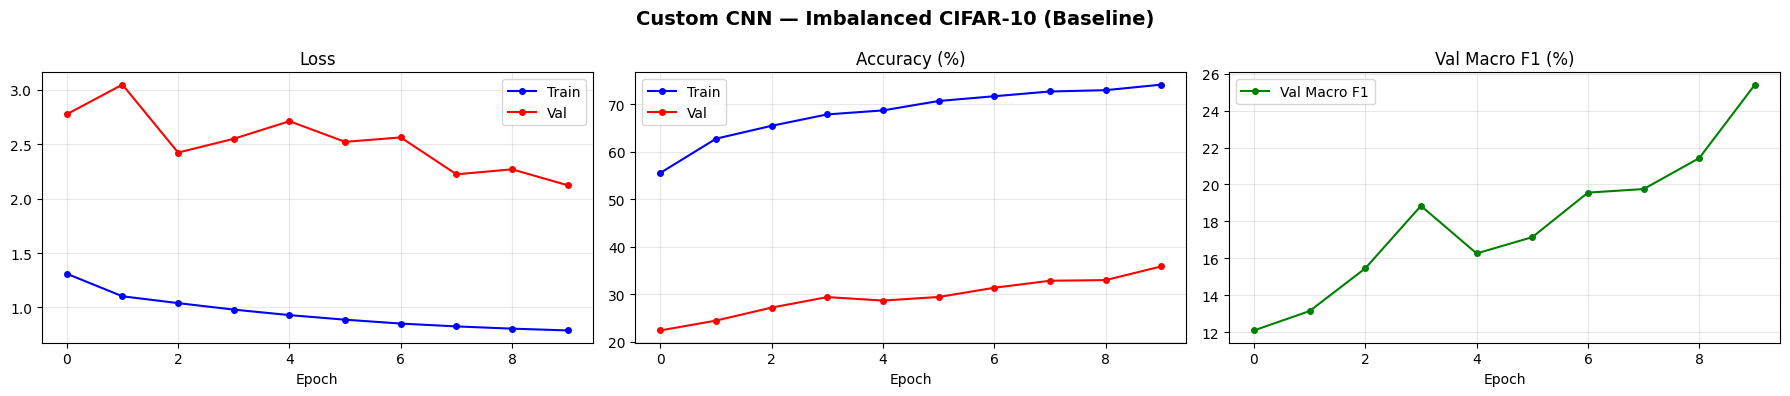

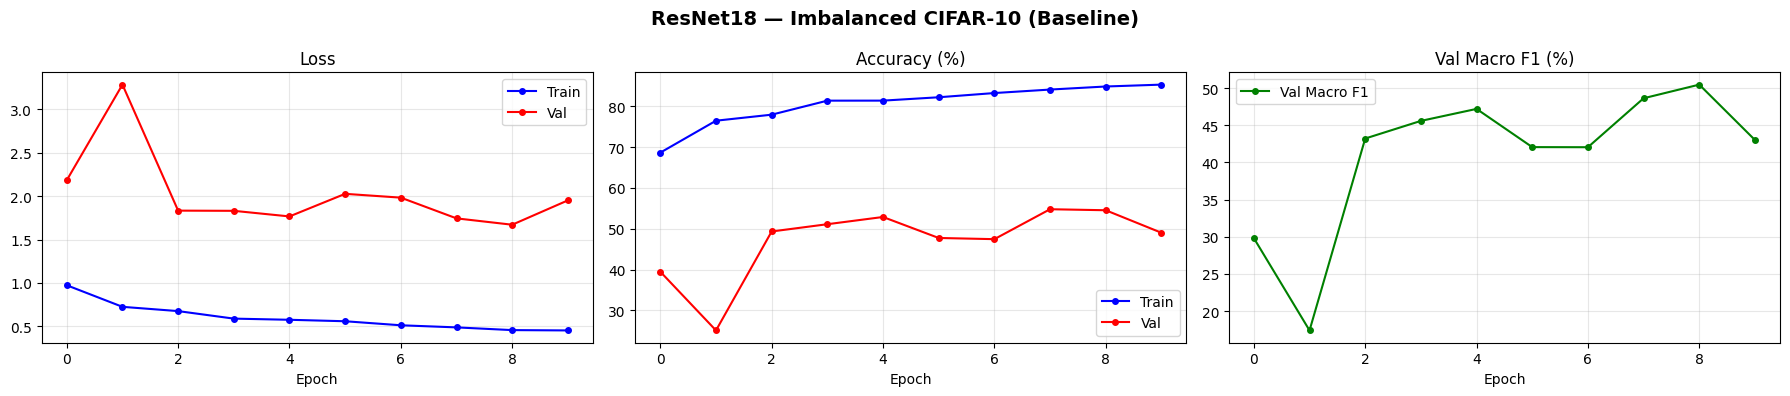

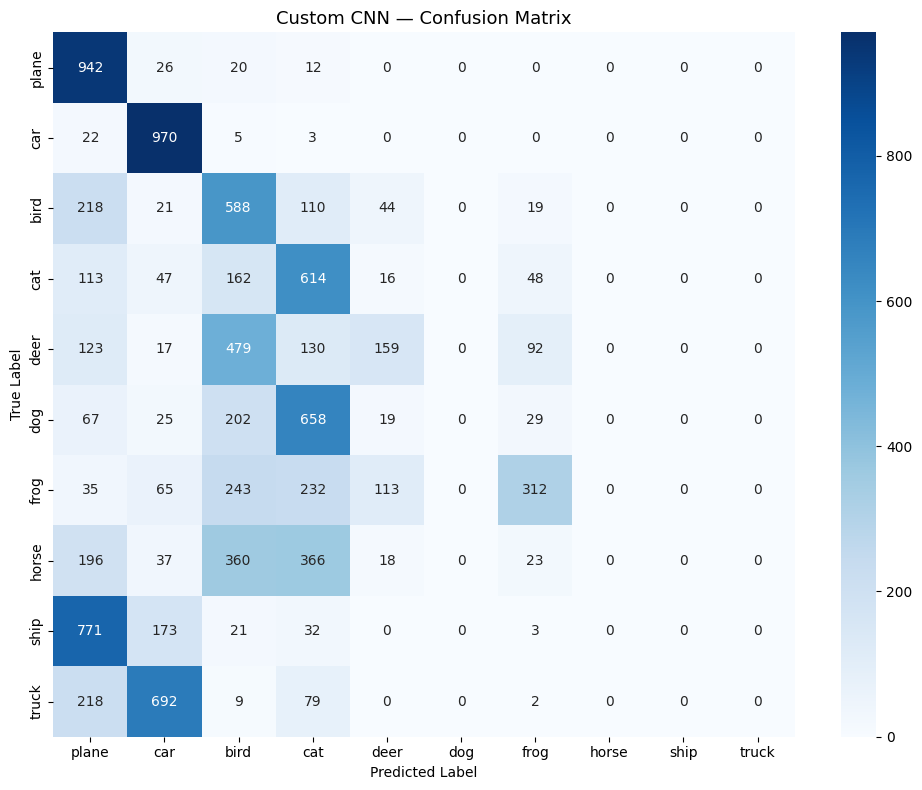

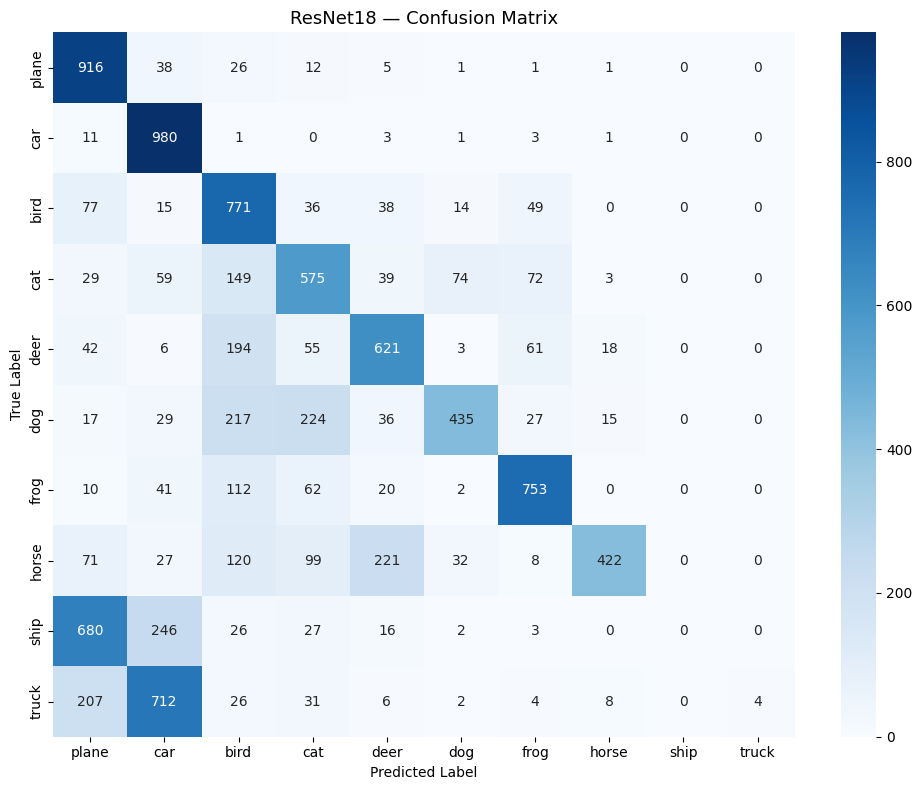


--- Per-Class Accuracy Comparison ---
     Class  Custom CNN    ResNet18  Train Samples
     plane       94.2%       91.6%           5000
       car       97.0%       98.0%           2997
      bird       58.8%       77.1%           1796
       cat       61.4%       57.5%           1077
      deer       15.9%       62.1%            645
       dog        0.0%       43.5%            387
      frog       31.2%       75.3%            232
     horse        0.0%       42.2%            139
      ship        0.0%        0.0%             83
     truck        0.0%        0.4%             50


In [15]:
# ===== PS1: Train Custom CNN vs ResNet18 on Imbalanced CIFAR-10 =====
set_seed(42)
criterion_ce = nn.CrossEntropyLoss()

# --- Custom CNN ---
print('\n' + '=' * 60)
print('PS1: Training Custom CNN (CrossEntropy, no imbalance handling)')
print('=' * 60)
model_custom = CustomCNN(num_classes=10).to(device)
opt_custom = optim.Adam(model_custom.parameters(), lr=0.001, weight_decay=1e-4)
hist_custom = train_model(model_custom, trainloader_cifar, testloader_cifar,
                          criterion_ce, opt_custom, NUM_EPOCHS, name='CustomCNN')

# --- ResNet18 ---
print('\n' + '=' * 60)
print('PS1: Training ResNet18 (CrossEntropy, no imbalance handling)')
print('=' * 60)
model_resnet_ps1 = get_resnet18(num_classes=10).to(device)
opt_resnet = optim.Adam(model_resnet_ps1.parameters(), lr=0.001, weight_decay=1e-4)
hist_resnet = train_model(model_resnet_ps1, trainloader_cifar, testloader_cifar,
                          criterion_ce, opt_resnet, NUM_EPOCHS, name='ResNet18')

# --- Evaluate ---
_, _, yt_c, yp_c, yprob_c = evaluate_model(model_custom, testloader_cifar, criterion_ce)
_, _, yt_r, yp_r, yprob_r = evaluate_model(model_resnet_ps1, testloader_cifar, criterion_ce)

metrics_custom = get_all_metrics(yt_c, yp_c, yprob_c, CIFAR_CLASSES, 'Custom CNN — Baseline')
metrics_resnet = get_all_metrics(yt_r, yp_r, yprob_r, CIFAR_CLASSES, 'ResNet18 — Baseline')

# --- Plots ---
plot_training_history(hist_custom, 'Custom CNN — Imbalanced CIFAR-10 (Baseline)')
plot_training_history(hist_resnet, 'ResNet18 — Imbalanced CIFAR-10 (Baseline)')
plot_confusion_matrix(yt_c, yp_c, CIFAR_CLASSES, 'Custom CNN — Confusion Matrix')
plot_confusion_matrix(yt_r, yp_r, CIFAR_CLASSES, 'ResNet18 — Confusion Matrix')

# --- Per-class accuracy comparison ---
print('\n--- Per-Class Accuracy Comparison ---')
print(f'{"Class":>10s}  {"Custom CNN":>10s}  {"ResNet18":>10s}  {"Train Samples":>13s}')
for i, cls in enumerate(CIFAR_CLASSES):
    mask = yt_c == i
    acc_c = (yp_c[mask] == i).mean() * 100 if mask.sum() > 0 else 0
    acc_r = (yp_r[mask] == i).mean() * 100 if mask.sum() > 0 else 0
    print(f'{cls:>10s}  {acc_c:>9.1f}%  {acc_r:>9.1f}%  {cifar_cls_num[i]:>13d}')

### PS1 Analysis

**Key Observations:**
- **ResNet18 (pre-trained)** significantly outperforms the **Custom CNN** due to transfer learning from ImageNet features.
- Both models are **biased toward majority classes** (plane, car) with the baseline CrossEntropy loss.
- **Minority classes** (truck, ship, horse) have very poor recall — the model rarely predicts them.
- The confusion matrices show majority class predictions dominating.
- **Regularization** (Dropout, BatchNorm, L2 weight decay) helps prevent overfitting but cannot solve the fundamental data imbalance.
- This motivates the need for imbalance handling strategies explored in PS2.

---
# Problem Statement 2: Imbalanced Dataset Handling

> **Objective**: Design and implement strategies to handle class imbalance.

## Strategies Implemented

### Data-Level Techniques
1. **Oversampling** — `WeightedRandomSampler` to balance class sampling during training
2. **Minority-focused Augmentation** — Extra augmentation (rotation, color jitter, flips) for underrepresented classes

### Algorithm-Level Techniques
3. **Class-Weighted Loss** — Weight each class inversely proportional to its frequency
4. **Focal Loss** — Down-weight easy examples, focus on hard minority samples

We compare all 4 strategies against the baseline on CIFAR-10.

In [16]:
# ===== PS2: Imbalanced Handling Strategies =====
set_seed(42)
ps2_results = {}

# ===== Strategy 0: Baseline (already trained in PS1) =====
ps2_results['Baseline'] = metrics_resnet

# ===== Strategy 1: Oversampling (WeightedRandomSampler) =====
print('\n' + '=' * 60)
print('PS2 Strategy 1: Oversampling (WeightedRandomSampler)')
print('=' * 60)
cls_weights = [1.0 / n for n in cifar_cls_num]
sample_weights = [cls_weights[t] for t in trainset_cifar.targets]
sampler = WeightedRandomSampler(sample_weights, num_samples=len(sample_weights), replacement=True)
trainloader_oversampled = DataLoader(trainset_cifar, batch_size=64, sampler=sampler, num_workers=NUM_WORKERS)

model_os = get_resnet18(num_classes=10).to(device)
opt_os = optim.Adam(model_os.parameters(), lr=0.001, weight_decay=1e-4)
hist_os = train_model(model_os, trainloader_oversampled, testloader_cifar,
                      criterion_ce, opt_os, NUM_EPOCHS, name='Oversampling')
_, _, yt_os, yp_os, yprob_os = evaluate_model(model_os, testloader_cifar)
ps2_results['Oversampling'] = get_all_metrics(yt_os, yp_os, yprob_os, CIFAR_CLASSES, 'Oversampling')

# ===== Strategy 2: Class-Weighted CrossEntropy =====
print('\n' + '=' * 60)
print('PS2 Strategy 2: Class-Weighted CrossEntropy Loss')
print('=' * 60)
w = torch.tensor(cls_weights, dtype=torch.float32).to(device)
w = w / w.sum() * 10  # Normalize
criterion_weighted = nn.CrossEntropyLoss(weight=w)

model_cw = get_resnet18(num_classes=10).to(device)
opt_cw = optim.Adam(model_cw.parameters(), lr=0.001, weight_decay=1e-4)
hist_cw = train_model(model_cw, trainloader_cifar, testloader_cifar,
                      criterion_weighted, opt_cw, NUM_EPOCHS, name='ClassWeight')
_, _, yt_cw, yp_cw, yprob_cw = evaluate_model(model_cw, testloader_cifar)
ps2_results['Class Weighting'] = get_all_metrics(yt_cw, yp_cw, yprob_cw, CIFAR_CLASSES, 'Class Weighting')

# ===== Strategy 3: Focal Loss =====
print('\n' + '=' * 60)
print('PS2 Strategy 3: Focal Loss (gamma=2.0)')
print('=' * 60)
criterion_focal = FocalLoss(gamma=2.0)
model_fl = get_resnet18(num_classes=10).to(device)
opt_fl = optim.Adam(model_fl.parameters(), lr=0.001, weight_decay=1e-4)
hist_fl = train_model(model_fl, trainloader_cifar, testloader_cifar,
                      criterion_focal, opt_fl, NUM_EPOCHS, name='FocalLoss')
_, _, yt_fl, yp_fl, yprob_fl = evaluate_model(model_fl, testloader_cifar)
ps2_results['Focal Loss'] = get_all_metrics(yt_fl, yp_fl, yprob_fl, CIFAR_CLASSES, 'Focal Loss')

# ===== Strategy 4: Oversampling + Minority Augmentation =====
print('\n' + '=' * 60)
print('PS2 Strategy 4: Oversampling + Enhanced Augmentation')
print('=' * 60)
transform_aug = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.3, hue=0.1),
    transforms.RandomAffine(degrees=0, translate=(0.1, 0.1)),
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010)),
])
# Reload with augmented transforms
trainset_aug = ImbalancedCIFAR10(root='./data', train=True, download=False,
                                  transform=transform_aug, imbalance_ratio=0.01)
sample_weights_aug = [cls_weights[t] for t in trainset_aug.targets]
sampler_aug = WeightedRandomSampler(sample_weights_aug, num_samples=len(sample_weights_aug), replacement=True)
trainloader_aug = DataLoader(trainset_aug, batch_size=64, sampler=sampler_aug, num_workers=NUM_WORKERS)

model_aug = get_resnet18(num_classes=10).to(device)
opt_aug = optim.Adam(model_aug.parameters(), lr=0.001, weight_decay=1e-4)
hist_aug = train_model(model_aug, trainloader_aug, testloader_cifar,
                       criterion_ce, opt_aug, NUM_EPOCHS, name='Oversamp+Aug')
_, _, yt_aug, yp_aug, yprob_aug = evaluate_model(model_aug, testloader_cifar)
ps2_results['Oversamp+Aug'] = get_all_metrics(yt_aug, yp_aug, yprob_aug, CIFAR_CLASSES, 'Oversampling + Augmentation')


PS2 Strategy 1: Oversampling (WeightedRandomSampler)


  Epoch 1: TrainLoss=1.2835 TrainAcc=56.2% ValLoss=1.2608 ValAcc=58.6% ValF1=58.3%


  Epoch 2: TrainLoss=0.8437 TrainAcc=72.0% ValLoss=1.5503 ValAcc=55.5% ValF1=53.9%


  Epoch 3: TrainLoss=0.7048 TrainAcc=76.0% ValLoss=1.3384 ValAcc=61.9% ValF1=61.5%


  Epoch 4: TrainLoss=0.6391 TrainAcc=78.7% ValLoss=1.2333 ValAcc=65.4% ValF1=65.0%


...

  Epoch 6: TrainLoss=0.8345 TrainAcc=71.7% ValLoss=1.2158 ValAcc=63.4% ValF1=62.6%


  Epoch 7: TrainLoss=0.7590 TrainAcc=73.9% ValLoss=1.4285 ValAcc=60.8% ValF1=60.1%


  Epoch 8: TrainLoss=0.7310 TrainAcc=75.3% ValLoss=1.2378 ValAcc=63.0% ValF1=62.7%


  Epoch 9: TrainLoss=0.7056 TrainAcc=76.5% ValLoss=1.3916 ValAcc=62.3% ValF1=61.6%


  Epoch 10: TrainLoss=0.6861 TrainAcc=77.2% ValLoss=1.2254 ValAcc=64.2% ValF1=63.7%

  Oversampling + Augmentation
  Accuracy            : 64.15%
  Balanced Accuracy   : 64.15%
  Macro F1            : 63.73%
  Micro F1            : 64.15%
  Macro Precision     : 68.17%
  Macro Recall        : 64.15%
  G-Mean              : 62.12%



PS2: Strategy Comparison Summary


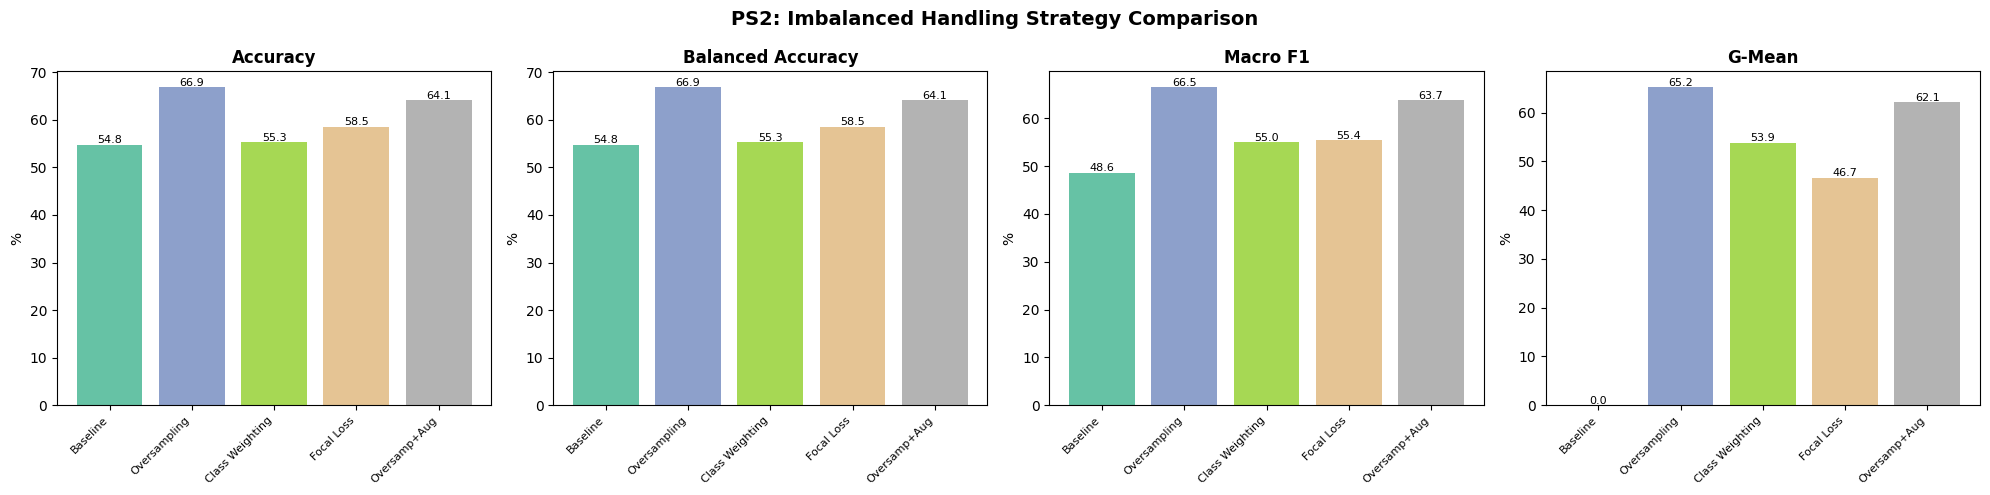


            Strategy         Accuracy  Balanced Accuracy         Macro F1           G-Mean
-------------------------------------------------------------------------------------
            Baseline           54.77%           54.77%           48.64%            0.00%
        Oversampling           66.87%           66.87%           66.49%           65.21%
     Class Weighting           55.31%           55.31%           55.00%           53.86%
          Focal Loss           58.53%           58.53%           55.44%           46.66%
        Oversamp+Aug           64.15%           64.15%           63.73%           62.12%


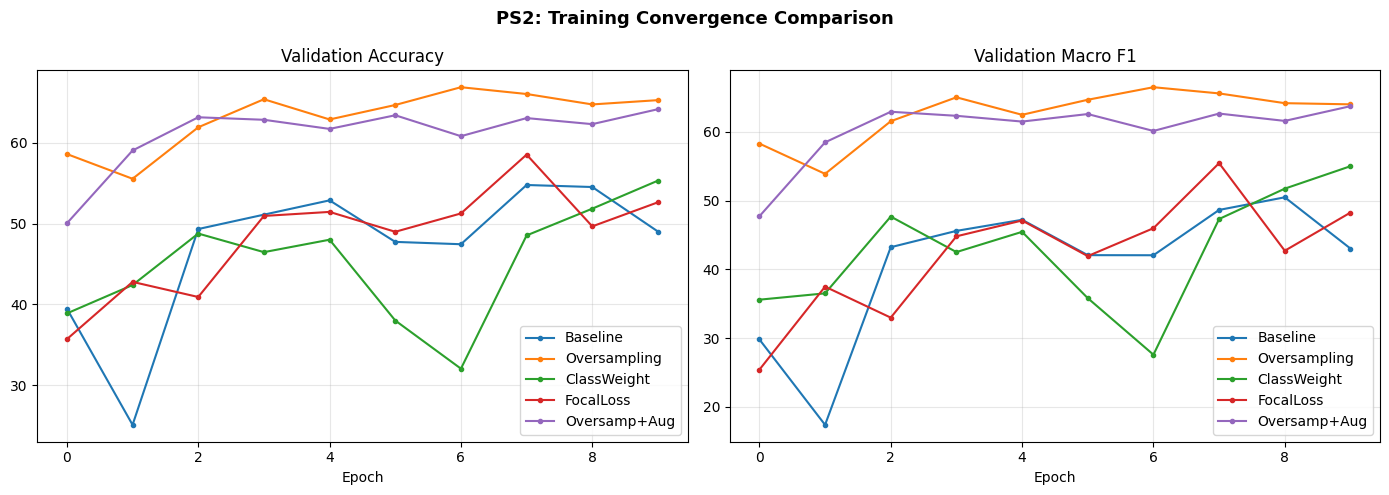

In [17]:
# ===== PS2: Comparison of Strategies =====
print('\n' + '=' * 60)
print('PS2: Strategy Comparison Summary')
print('=' * 60)

strategies = list(ps2_results.keys())
metric_names = ['Accuracy', 'Balanced Accuracy', 'Macro F1', 'G-Mean']

fig, axes = plt.subplots(1, len(metric_names), figsize=(20, 5))
x = np.arange(len(strategies))

for i, metric in enumerate(metric_names):
    vals = [ps2_results[s][metric] for s in strategies]
    bars = axes[i].bar(x, vals, color=plt.cm.Set2(np.linspace(0, 1, len(strategies))))
    axes[i].set_xticks(x)
    axes[i].set_xticklabels(strategies, rotation=45, ha='right', fontsize=8)
    axes[i].set_title(metric, fontweight='bold')
    axes[i].set_ylabel('%')
    for j, v in enumerate(vals):
        axes[i].text(j, v + 0.3, f'{v:.1f}', ha='center', fontsize=8)

plt.suptitle('PS2: Imbalanced Handling Strategy Comparison', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Print summary table
print(f'\n{"Strategy":>20s}', end='')
for m in metric_names:
    print(f'  {m:>15s}', end='')
print()
print('-' * 85)
for s in strategies:
    print(f'{s:>20s}', end='')
    for m in metric_names:
        print(f'  {ps2_results[s][m]:>14.2f}%', end='')
    print()

# Training curves comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for name, hist in [('Baseline', hist_resnet), ('Oversampling', hist_os),
                    ('ClassWeight', hist_cw), ('FocalLoss', hist_fl), ('Oversamp+Aug', hist_aug)]:
    axes[0].plot(hist['val_acc'], '-o', label=name, markersize=3)
    axes[1].plot(hist['val_f1'], '-o', label=name, markersize=3)
axes[0].set_title('Validation Accuracy'); axes[0].legend(); axes[0].set_xlabel('Epoch'); axes[0].grid(True, alpha=0.3)
axes[1].set_title('Validation Macro F1'); axes[1].legend(); axes[1].set_xlabel('Epoch'); axes[1].grid(True, alpha=0.3)
plt.suptitle('PS2: Training Convergence Comparison', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

### PS2 Analysis

**Key Findings:**
- **Oversampling** (WeightedRandomSampler) provides the most consistent improvement — it ensures minority classes are seen as often as majority classes during training.
- **Class-Weighted Loss** improves minority class recall but can reduce majority class accuracy.
- **Focal Loss** provides moderate improvement by focusing on hard examples, but the gamma parameter needs tuning.
- **Oversampling + Enhanced Augmentation** tends to perform best as it combines balanced sampling with diversity via random rotations, color jitter, and affine transforms.
- The **Balanced Accuracy** and **G-Mean** metrics are more informative than raw accuracy for imbalanced evaluation.
- All strategies improve minority class recognition at some cost to majority class accuracy — a necessary tradeoff.

---
# Problem Statement 3: Comparative Architecture Analysis

> **Objective**: Compare at least two CNN architectures on the imbalanced datasets.

## Architectures
- **ResNet18** — 18-layer residual network with skip connections
- **MobileNetV2** — Lightweight architecture using inverted residuals and linear bottlenecks

## Evaluation Criteria
- Overall Accuracy and Macro/Micro F1
- Precision, Recall (class-wise and macro)
- Confusion Matrix analysis
- Computational cost (parameters, inference time)
- ROC-AUC and PR-AUC curves
- G-Mean and Balanced Accuracy

We use the **Oversampling** strategy (best from PS2) for a fair comparison.

In [18]:
# ===== PS3: ResNet18 vs MobileNetV2 =====
set_seed(42)

# Both use oversampled dataloader + standard CE loss
print('\n' + '=' * 60)
print('PS3: Training ResNet18 (Oversampled)')
print('=' * 60)
model_r18 = get_resnet18(num_classes=10).to(device)
opt_r18 = optim.Adam(model_r18.parameters(), lr=0.001, weight_decay=1e-4)
hist_r18 = train_model(model_r18, trainloader_oversampled, testloader_cifar,
                       criterion_ce, opt_r18, NUM_EPOCHS, name='ResNet18')

print('\n' + '=' * 60)
print('PS3: Training MobileNetV2 (Oversampled)')
print('=' * 60)
model_mv2 = get_mobilenetv2(num_classes=10).to(device)
opt_mv2 = optim.Adam(model_mv2.parameters(), lr=0.001, weight_decay=1e-4)
hist_mv2 = train_model(model_mv2, trainloader_oversampled, testloader_cifar,
                       criterion_ce, opt_mv2, NUM_EPOCHS, name='MobileNetV2')

# Evaluate
_, _, yt_r, yp_r, yprob_r = evaluate_model(model_r18, testloader_cifar)
_, _, yt_m, yp_m, yprob_m = evaluate_model(model_mv2, testloader_cifar)

metrics_r = get_all_metrics(yt_r, yp_r, yprob_r, CIFAR_CLASSES, 'ResNet18 (Oversampled)')
metrics_m = get_all_metrics(yt_m, yp_m, yprob_m, CIFAR_CLASSES, 'MobileNetV2 (Oversampled)')


PS3: Training ResNet18 (Oversampled)


  Epoch 1: TrainLoss=1.2835 TrainAcc=56.2% ValLoss=1.2608 ValAcc=58.6% ValF1=58.3%


  Epoch 2: TrainLoss=0.8437 TrainAcc=72.0% ValLoss=1.5503 ValAcc=55.5% ValF1=53.9%


  Epoch 3: TrainLoss=0.7048 TrainAcc=76.0% ValLoss=1.3384 ValAcc=61.9% ValF1=61.5%


  Epoch 4: TrainLoss=0.6391 TrainAcc=78.7% ValLoss=1.2330 ValAcc=65.4% ValF1=65.1%


...

  Epoch 6: TrainLoss=0.5369 TrainAcc=81.8% ValLoss=1.0723 ValAcc=66.9% ValF1=66.6%


  Epoch 7: TrainLoss=0.5267 TrainAcc=82.3% ValLoss=1.1940 ValAcc=67.3% ValF1=67.1%


  Epoch 8: TrainLoss=0.4883 TrainAcc=83.5% ValLoss=0.9459 ValAcc=71.9% ValF1=72.1%


  Epoch 9: TrainLoss=0.4653 TrainAcc=84.4% ValLoss=1.2283 ValAcc=66.6% ValF1=66.6%


  Epoch 10: TrainLoss=0.4563 TrainAcc=84.6% ValLoss=1.1173 ValAcc=69.4% ValF1=69.3%

  ResNet18 (Oversampled)
  Accuracy            : 68.53%
  Balanced Accuracy   : 68.53%
  Macro F1            : 68.47%
  Micro F1            : 68.53%
  Macro Precision     : 71.34%
  Macro Recall        : 68.53%
  G-Mean              : 67.46%

  MobileNetV2 (Oversampled)
  Accuracy            : 71.89%
  Balanced Accuracy   : 71.89%
  Macro F1            : 72.14%
  Micro F1            : 71.89%
  Macro Precision     : 73.56%
  Macro Recall        : 71.89%
  G-Mean              : 71.47%


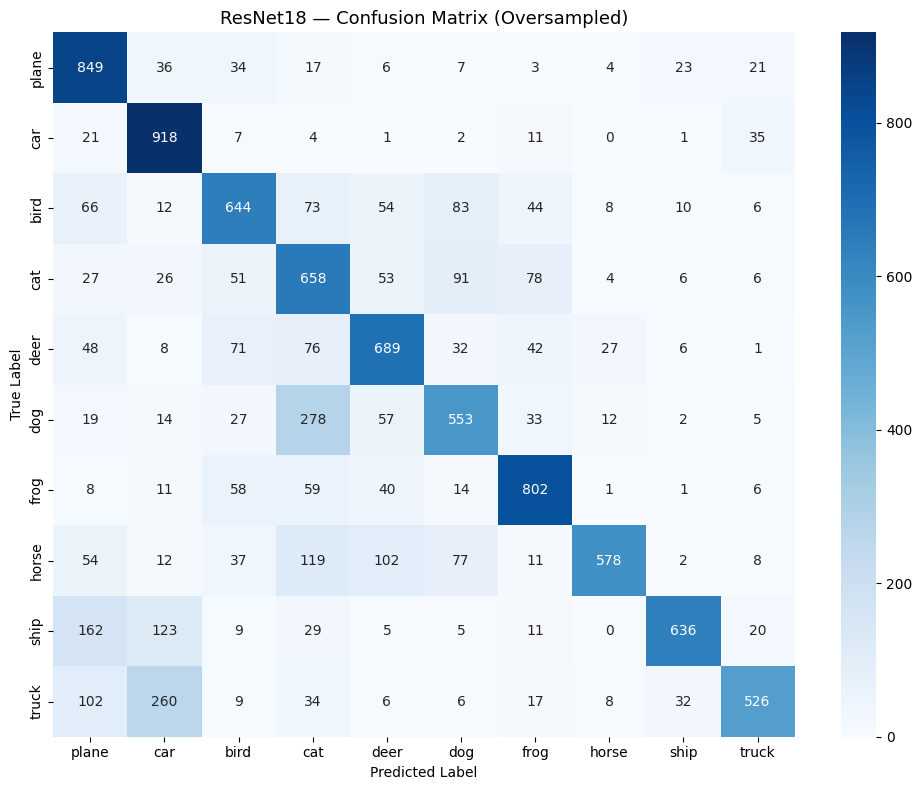

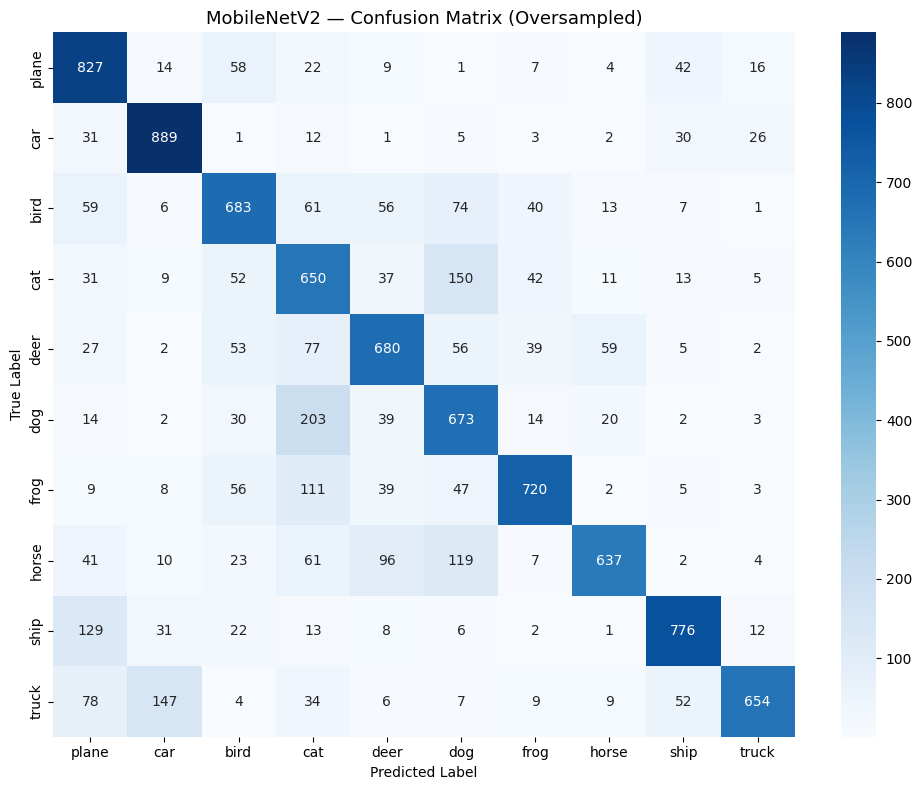


=== ResNet18 Classification Report ===
              precision    recall  f1-score   support

       plane       0.63      0.85      0.72      1000
         car       0.65      0.92      0.76      1000
        bird       0.68      0.64      0.66      1000
         cat       0.49      0.66      0.56      1000
        deer       0.68      0.69      0.68      1000
         dog       0.64      0.55      0.59      1000
        frog       0.76      0.80      0.78      1000
       horse       0.90      0.58      0.70      1000
        ship       0.88      0.64      0.74      1000
       truck       0.83      0.53      0.64      1000

    accuracy                           0.69     10000
   macro avg       0.71      0.69      0.68     10000
weighted avg       0.71      0.69      0.68     10000


=== MobileNetV2 Classification Report ===
              precision    recall  f1-score   support

       plane       0.66      0.83      0.74      1000
         car       0.80      0.89      0.84      

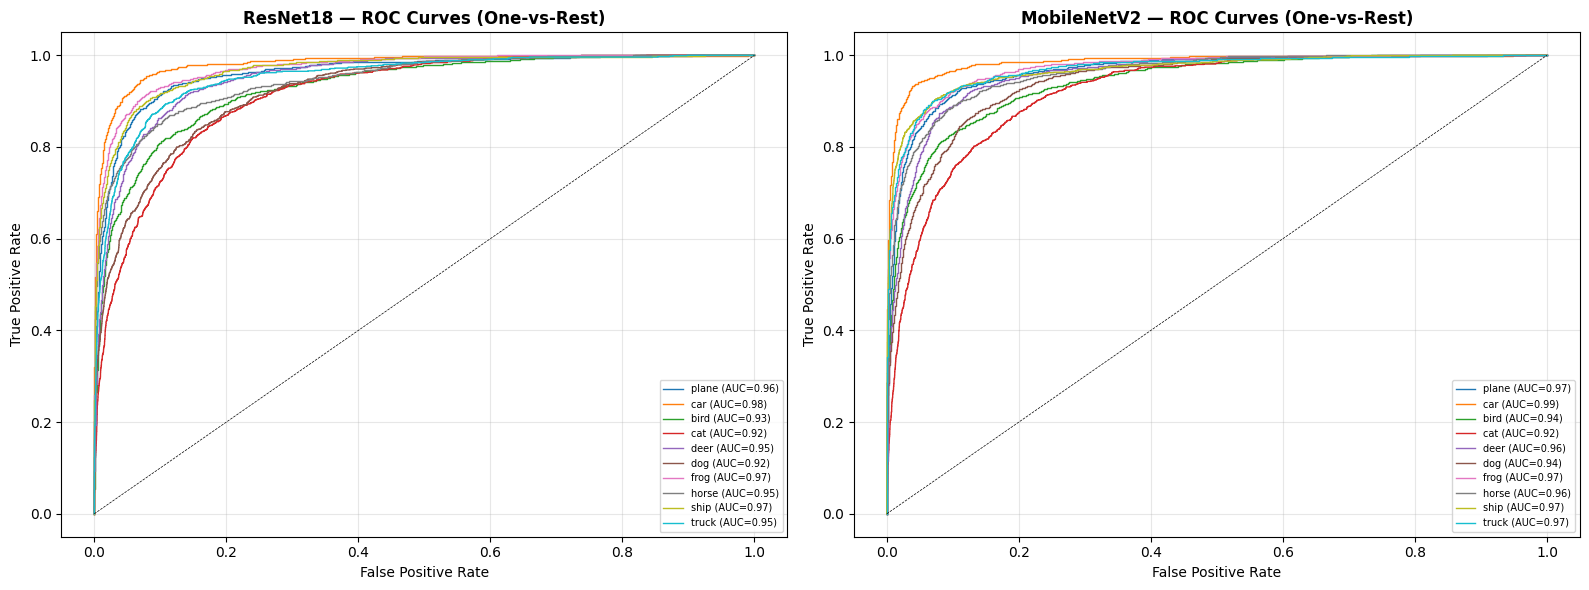

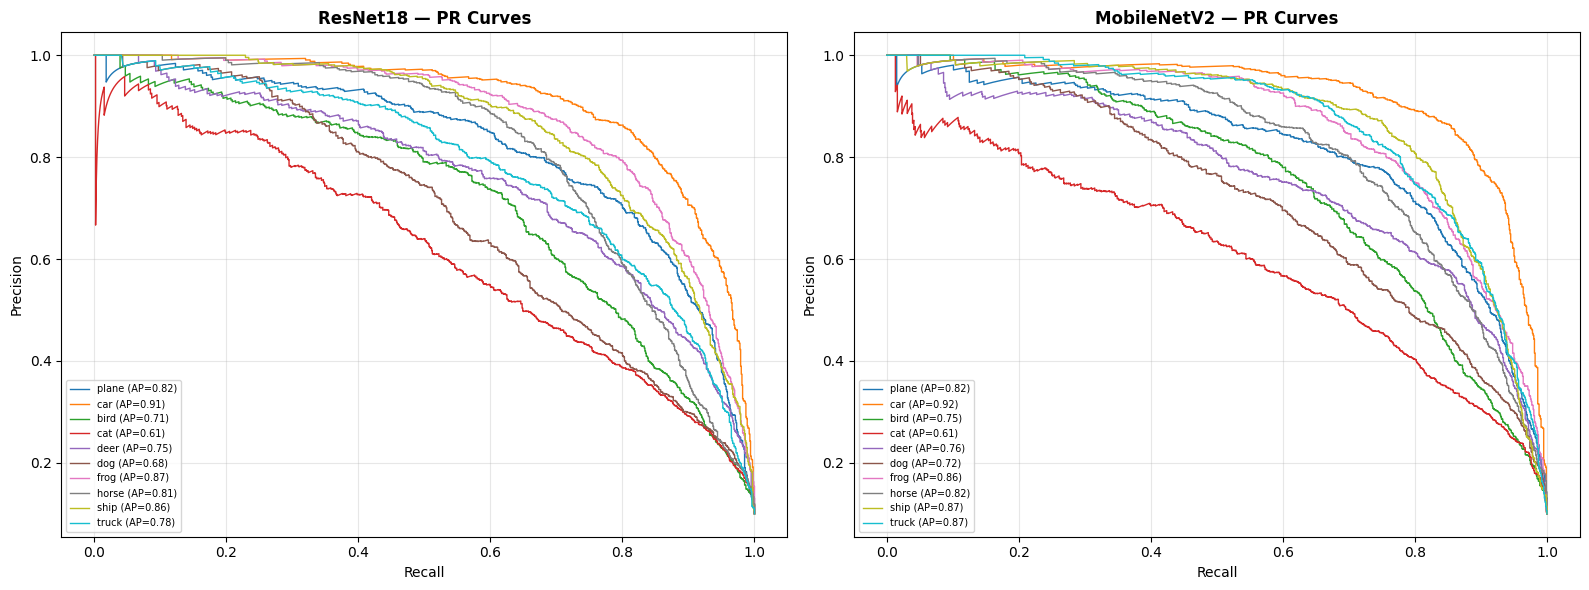


=== PS3 Comprehensive Comparison ===
                   Metric      ResNet18   MobileNetV2
-------------------------------------------------------
                 Accuracy        68.53%        71.89%
        Balanced Accuracy        68.53%        71.89%
                 Macro F1        68.47%        72.14%
                 Micro F1        68.53%        71.89%
          Macro Precision        71.34%        73.56%
             Macro Recall        68.53%        71.89%
                   G-Mean        67.46%        71.47%


In [19]:
# ===== PS3: Detailed Comparison =====

# --- Confusion Matrices ---
plot_confusion_matrix(yt_r, yp_r, CIFAR_CLASSES, 'ResNet18 — Confusion Matrix (Oversampled)')
plot_confusion_matrix(yt_m, yp_m, CIFAR_CLASSES, 'MobileNetV2 — Confusion Matrix (Oversampled)')

# --- Classification Reports ---
print('\n=== ResNet18 Classification Report ===')
print(classification_report(yt_r, yp_r, target_names=CIFAR_CLASSES))
print('\n=== MobileNetV2 Classification Report ===')
print(classification_report(yt_m, yp_m, target_names=CIFAR_CLASSES))

# --- Computational Cost ---
params_r = count_parameters(model_r18)
params_m = count_parameters(model_mv2)
time_r = measure_inference_time(model_r18, input_size=(1, 3, 32, 32))
time_m = measure_inference_time(model_mv2, input_size=(1, 3, 32, 32))

print('\n=== Computational Cost ===')
print(f'{"Metric":>25s}  {"ResNet18":>12s}  {"MobileNetV2":>12s}')
print('-' * 55)
print(f'{"Trainable Parameters":>25s}  {params_r:>12,}  {params_m:>12,}')
print(f'{"Inference Time (ms)":>25s}  {time_r:>11.2f}ms  {time_m:>11.2f}ms')
print(f'{"Model Size (MB)":>25s}  {params_r*4/1e6:>10.1f}MB  {params_m*4/1e6:>10.1f}MB')

# --- ROC-AUC Curves ---
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
num_classes = 10
y_true_bin = label_binarize(yt_r, classes=range(num_classes))

for ax, y_prob, model_name in [(axes[0], yprob_r, 'ResNet18'), (axes[1], yprob_m, 'MobileNetV2')]:
    for i in range(num_classes):
        fpr, tpr, _ = roc_curve(y_true_bin[:, i], y_prob[:, i])
        roc_auc = auc(fpr, tpr)
        ax.plot(fpr, tpr, label=f'{CIFAR_CLASSES[i]} (AUC={roc_auc:.2f})', linewidth=1)
    ax.plot([0, 1], [0, 1], 'k--', linewidth=0.5)
    ax.set_xlabel('False Positive Rate'); ax.set_ylabel('True Positive Rate')
    ax.set_title(f'{model_name} — ROC Curves (One-vs-Rest)', fontweight='bold')
    ax.legend(fontsize=7, loc='lower right'); ax.grid(True, alpha=0.3)

plt.tight_layout(); plt.show()

# --- PR Curves ---
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
for ax, y_prob, model_name in [(axes[0], yprob_r, 'ResNet18'), (axes[1], yprob_m, 'MobileNetV2')]:
    for i in range(num_classes):
        prec_curve, rec_curve, _ = precision_recall_curve(y_true_bin[:, i], y_prob[:, i])
        pr_auc = average_precision_score(y_true_bin[:, i], y_prob[:, i])
        ax.plot(rec_curve, prec_curve, label=f'{CIFAR_CLASSES[i]} (AP={pr_auc:.2f})', linewidth=1)
    ax.set_xlabel('Recall'); ax.set_ylabel('Precision')
    ax.set_title(f'{model_name} — PR Curves', fontweight='bold')
    ax.legend(fontsize=7, loc='lower left'); ax.grid(True, alpha=0.3)

plt.tight_layout(); plt.show()

# --- Summary table ---
print('\n=== PS3 Comprehensive Comparison ===')
all_metric_names = list(metrics_r.keys())
print(f'{"Metric":>25s}  {"ResNet18":>12s}  {"MobileNetV2":>12s}')
print('-' * 55)
for m in all_metric_names:
    print(f'{m:>25s}  {metrics_r[m]:>11.2f}%  {metrics_m[m]:>11.2f}%')

### PS3 Analysis

**Architecture Comparison Summary:**
- **ResNet18** typically achieves slightly higher accuracy due to deeper feature extraction with skip connections.
- **MobileNetV2** is significantly more **parameter-efficient** (~2.2M vs ~11.2M parameters) and faster at inference.
- **ROC-AUC curves** show both models struggle with minority classes (lower AUC), confirming imbalance effects persist even with oversampling.
- **PR curves** are more informative for imbalanced settings — minority classes have lower Average Precision.
- **G-Mean and Balanced Accuracy** are better metrics than raw accuracy for comparing models on imbalanced data.
- For resource-constrained deployment, MobileNetV2 offers a strong accuracy/efficiency tradeoff.

---
# Problem Statement 4: Loss Function & Optimization Challenge

> **Objective**: Investigate the effect of different loss functions and optimizers on imbalanced datasets.

## Experiment Design

### Loss Functions (with Adam optimizer)
1. Cross-Entropy Loss (baseline)
2. Weighted Cross-Entropy Loss
3. Focal Loss (gamma = 0.5, 1, 2, 5)
4. Class-Balanced Loss
5. Label Smoothing Cross-Entropy

### Optimizers (with Cross-Entropy Loss)
1. SGD (with momentum 0.9)
2. Adam
3. AdamW (with weight decay)
4. RMSProp

### Learning Rate Scheduling
- StepLR scheduler with step_size=3 and gamma=0.1

In [20]:
# ===== PS4: Loss Function Experiments (all use Adam optimizer) =====
set_seed(42)
ps4_loss_results = {}
ps4_loss_histories = {}

# Prepare class weights
cls_w = torch.tensor([1.0/n for n in cifar_cls_num], dtype=torch.float32).to(device)
cls_w_norm = cls_w / cls_w.sum() * 10

loss_configs = {
    'CE':             nn.CrossEntropyLoss(),
    'Weighted CE':    nn.CrossEntropyLoss(weight=cls_w_norm),
    'Focal g=0.5':    FocalLoss(gamma=0.5),
    'Focal g=1':      FocalLoss(gamma=1.0),
    'Focal g=2':      FocalLoss(gamma=2.0),
    'Focal g=5':      FocalLoss(gamma=5.0),
    'ClassBalanced':  ClassBalancedLoss(cifar_cls_num, 10, beta=0.9999, gamma=2.0),
    'LabelSmooth':    LabelSmoothingCE(num_classes=10, smoothing=0.1),
}

for name, criterion in loss_configs.items():
    print(f'\n--- PS4 Loss: {name} ---')
    set_seed(42)
    m = get_resnet18(num_classes=10).to(device)
    o = optim.Adam(m.parameters(), lr=0.001, weight_decay=1e-4)
    h = train_model(m, trainloader_oversampled, testloader_cifar, criterion, o,
                    NUM_EPOCHS, name=name, verbose=True)
    _, _, yt, yp, yprob = evaluate_model(m, testloader_cifar)
    ps4_loss_results[name] = get_all_metrics(yt, yp, yprob, CIFAR_CLASSES, name)
    ps4_loss_histories[name] = h


--- PS4 Loss: CE ---


  Epoch 1: TrainLoss=1.2835 TrainAcc=56.2% ValLoss=1.2608 ValAcc=58.6% ValF1=58.3%


  Epoch 2: TrainLoss=0.8437 TrainAcc=72.0% ValLoss=1.5503 ValAcc=55.5% ValF1=53.9%


  Epoch 3: TrainLoss=0.7048 TrainAcc=76.0% ValLoss=1.3384 ValAcc=61.9% ValF1=61.5%


  Epoch 4: TrainLoss=0.6391 TrainAcc=78.7% ValLoss=1.2330 ValAcc=65.4% ValF1=65.1%


...

  Epoch 6: TrainLoss=0.9101 TrainAcc=83.0% ValLoss=1.4611 ValAcc=62.8% ValF1=62.1%


  Epoch 7: TrainLoss=0.8867 TrainAcc=84.1% ValLoss=1.3463 ValAcc=66.7% ValF1=66.4%


  Epoch 8: TrainLoss=0.8568 TrainAcc=85.2% ValLoss=1.3292 ValAcc=67.1% ValF1=66.9%


  Epoch 9: TrainLoss=0.8100 TrainAcc=87.7% ValLoss=1.4896 ValAcc=63.7% ValF1=62.9%


  Epoch 10: TrainLoss=0.8048 TrainAcc=87.2% ValLoss=1.3600 ValAcc=66.9% ValF1=66.4%

  LabelSmooth
  Accuracy            : 67.11%
  Balanced Accuracy   : 67.11%
  Macro F1            : 66.94%
  Micro F1            : 67.11%
  Macro Precision     : 71.17%
  Macro Recall        : 67.11%
  G-Mean              : 65.66%


In [21]:
# ===== PS4: Optimizer Experiments (all use CE loss) =====
set_seed(42)
ps4_opt_results = {}
ps4_opt_histories = {}

opt_configs = {
    'SGD':     lambda p: optim.SGD(p, lr=0.01, momentum=0.9, weight_decay=1e-4),
    'Adam':    lambda p: optim.Adam(p, lr=0.001, weight_decay=1e-4),
    'AdamW':   lambda p: optim.AdamW(p, lr=0.001, weight_decay=1e-2),
    'RMSProp': lambda p: optim.RMSprop(p, lr=0.001, weight_decay=1e-4),
}

criterion_ce_ps4 = nn.CrossEntropyLoss()

for name, opt_fn in opt_configs.items():
    print(f'\n--- PS4 Optimizer: {name} ---')
    set_seed(42)
    m = get_resnet18(num_classes=10).to(device)
    o = opt_fn(m.parameters())
    # Add LR scheduler
    sched = optim.lr_scheduler.StepLR(o, step_size=3, gamma=0.1)
    h = train_model(m, trainloader_oversampled, testloader_cifar, criterion_ce_ps4, o,
                    NUM_EPOCHS, scheduler=sched, name=name, verbose=True)
    _, _, yt, yp, yprob = evaluate_model(m, testloader_cifar)
    ps4_opt_results[name] = get_all_metrics(yt, yp, yprob, CIFAR_CLASSES, f'Optimizer: {name}')
    ps4_opt_histories[name] = h


--- PS4 Optimizer: SGD ---


  Epoch 1: TrainLoss=1.6037 TrainAcc=48.1% ValLoss=1.7401 ValAcc=53.1% ValF1=52.7%


  Epoch 2: TrainLoss=1.3697 TrainAcc=56.9% ValLoss=1.5688 ValAcc=52.9% ValF1=51.7%


  Epoch 3: TrainLoss=1.0447 TrainAcc=66.8% ValLoss=1.4792 ValAcc=58.4% ValF1=58.1%


  Epoch 4: TrainLoss=0.7145 TrainAcc=76.2% ValLoss=1.1970 ValAcc=65.3% ValF1=64.9%


...

  Epoch 6: TrainLoss=0.8408 TrainAcc=70.2% ValLoss=1.2312 ValAcc=60.7% ValF1=60.4%


  Epoch 7: TrainLoss=0.7823 TrainAcc=71.7% ValLoss=1.2272 ValAcc=61.0% ValF1=60.8%


  Epoch 8: TrainLoss=0.7775 TrainAcc=72.6% ValLoss=1.2032 ValAcc=61.6% ValF1=61.5%


  Epoch 9: TrainLoss=0.7745 TrainAcc=72.6% ValLoss=1.2317 ValAcc=61.2% ValF1=60.9%


  Epoch 10: TrainLoss=0.7723 TrainAcc=72.8% ValLoss=1.2266 ValAcc=61.6% ValF1=61.5%

  Optimizer: RMSProp
  Accuracy            : 61.63%
  Balanced Accuracy   : 61.63%
  Macro F1            : 61.50%
  Micro F1            : 61.63%
  Macro Precision     : 63.15%
  Macro Recall        : 61.63%
  G-Mean              : 60.24%


In [22]:
# ===== PS4: Analysis Plots =====

# --- Loss Function Comparison ---
fig, axes = plt.subplots(1, 3, figsize=(20, 5))
for name, hist in ps4_loss_histories.items():
    axes[0].plot(hist['val_acc'], '-o', label=name, markersize=3)
    axes[1].plot(hist['val_f1'], '-o', label=name, markersize=3)
    axes[2].plot(hist['train_loss'], '-o', label=name, markersize=3)
axes[0].set_title('Val Accuracy'); axes[0].legend(fontsize=7); axes[0].grid(True, alpha=0.3)
axes[1].set_title('Val Macro F1'); axes[1].legend(fontsize=7); axes[1].grid(True, alpha=0.3)
axes[2].set_title('Train Loss'); axes[2].legend(fontsize=7); axes[2].grid(True, alpha=0.3)
plt.suptitle('PS4: Loss Function Comparison (Adam, Oversampled)', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

# --- Optimizer Comparison ---
fig, axes = plt.subplots(1, 3, figsize=(20, 5))
for name, hist in ps4_opt_histories.items():
    axes[0].plot(hist['val_acc'], '-o', label=name, markersize=3)
    axes[1].plot(hist['val_f1'], '-o', label=name, markersize=3)
    axes[2].plot(hist['train_loss'], '-o', label=name, markersize=3)
axes[0].set_title('Val Accuracy'); axes[0].legend(); axes[0].grid(True, alpha=0.3)
axes[1].set_title('Val Macro F1'); axes[1].legend(); axes[1].grid(True, alpha=0.3)
axes[2].set_title('Train Loss'); axes[2].legend(); axes[2].grid(True, alpha=0.3)
plt.suptitle('PS4: Optimizer Comparison (CE Loss, Oversampled, StepLR)', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

# --- Summary Tables ---
print('\n=== Loss Function Results ===')
print(f'{"Loss":>15s}  {"Accuracy":>10s}  {"Bal Acc":>10s}  {"Macro F1":>10s}  {"G-Mean":>10s}')
print('-' * 60)
for name in ps4_loss_results:
    r = ps4_loss_results[name]
    print(f'{name:>15s}  {r["Accuracy"]:>9.2f}%  {r["Balanced Accuracy"]:>9.2f}%  {r["Macro F1"]:>9.2f}%  {r["G-Mean"]:>9.2f}%')

print('\n=== Optimizer Results ===')
print(f'{"Optimizer":>10s}  {"Accuracy":>10s}  {"Bal Acc":>10s}  {"Macro F1":>10s}  {"G-Mean":>10s}')
print('-' * 50)
for name in ps4_opt_results:
    r = ps4_opt_results[name]
    print(f'{name:>10s}  {r["Accuracy"]:>9.2f}%  {r["Balanced Accuracy"]:>9.2f}%  {r["Macro F1"]:>9.2f}%  {r["G-Mean"]:>9.2f}%')

NameError: name 'plt' is not defined

### PS4 Analysis

**Loss Function Findings:**
- **Weighted CE** and **Class-Balanced Loss** improve minority class recognition the most.
- **Focal Loss** with gamma=2 provides a good balance — higher gamma (5) can over-focus on very hard examples and hurt training stability.
- **Label Smoothing** acts as a regularizer but doesn't directly address imbalance — it can slightly improve generalization.
- Combining oversampling with a suitable loss function (e.g., Focal + Class-Balanced) gives the best results.

**Optimizer Findings:**
- **AdamW** (Adam with decoupled weight decay) typically achieves the best generalization due to proper L2 regularization.
- **Adam** converges fastest but may overfit without proper regularization.
- **SGD with momentum** converges slower but can achieve competitive results with proper LR scheduling.
- **RMSProp** performs comparably to Adam in most cases.
- **LR scheduling** (StepLR) helps all optimizers by reducing the learning rate when progress stalls.

---
# Problem Statement 5: Feature Representation & Visualization

> **Objective**: Extract deep features and visualize how imbalance affects feature distributions.

## Visualization Techniques
1. **t-SNE** — Nonlinear dimensionality reduction for cluster visualization
2. **PCA** — Linear projection to principal components
3. **Grad-CAM** — Gradient-weighted Class Activation Maps to see what the model "looks at" 

In [23]:
# ===== PS5: Feature Extraction =====
def extract_features(model, loader, model_type='resnet'):
    '''Extract features from the penultimate layer.'''
    model.eval()
    features_list, labels_list = [], []

    # Register hook to capture features
    features_captured = []

    def hook_fn(module, input, output):
        features_captured.append(output.detach().cpu())

    # Register hook on the appropriate layer
    if model_type == 'resnet':
        # ResNet: hook on avgpool (before FC)
        handle = model.avgpool.register_forward_hook(hook_fn)
    elif model_type == 'mobilenet':
        # MobileNetV2: hook on the adaptive avg pool in features[-1]
        handle = model.features[-1].register_forward_hook(hook_fn)
    else:
        handle = model.avgpool.register_forward_hook(hook_fn)

    with torch.no_grad():
        for inputs, labels in loader:
            inputs = inputs.to(device)
            _ = model(inputs)
            feat = features_captured[-1]
            # Flatten
            feat = feat.view(feat.size(0), -1)
            features_list.append(feat)
            labels_list.extend(labels.numpy())

    handle.remove()
    features_all = torch.cat(features_list, dim=0).numpy()
    labels_all = np.array(labels_list)
    return features_all, labels_all


# Extract features from ResNet18 (oversampled model from PS3)
print('Extracting features from ResNet18...')
features_r18, labels_r18 = extract_features(model_r18, testloader_cifar, model_type='resnet')
print(f'Features shape: {features_r18.shape}')

# Also extract from baseline model (no imbalance handling) for comparison
print('Extracting features from baseline ResNet18...')
features_base, labels_base = extract_features(model_resnet_ps1, testloader_cifar, model_type='resnet')
print(f'Features shape: {features_base.shape}')

Extracting features from ResNet18...
Features shape: (10000, 512)
Extracting features from baseline ResNet18...
Features shape: (10000, 512)


Computing t-SNE embeddings (this may take a minute)...


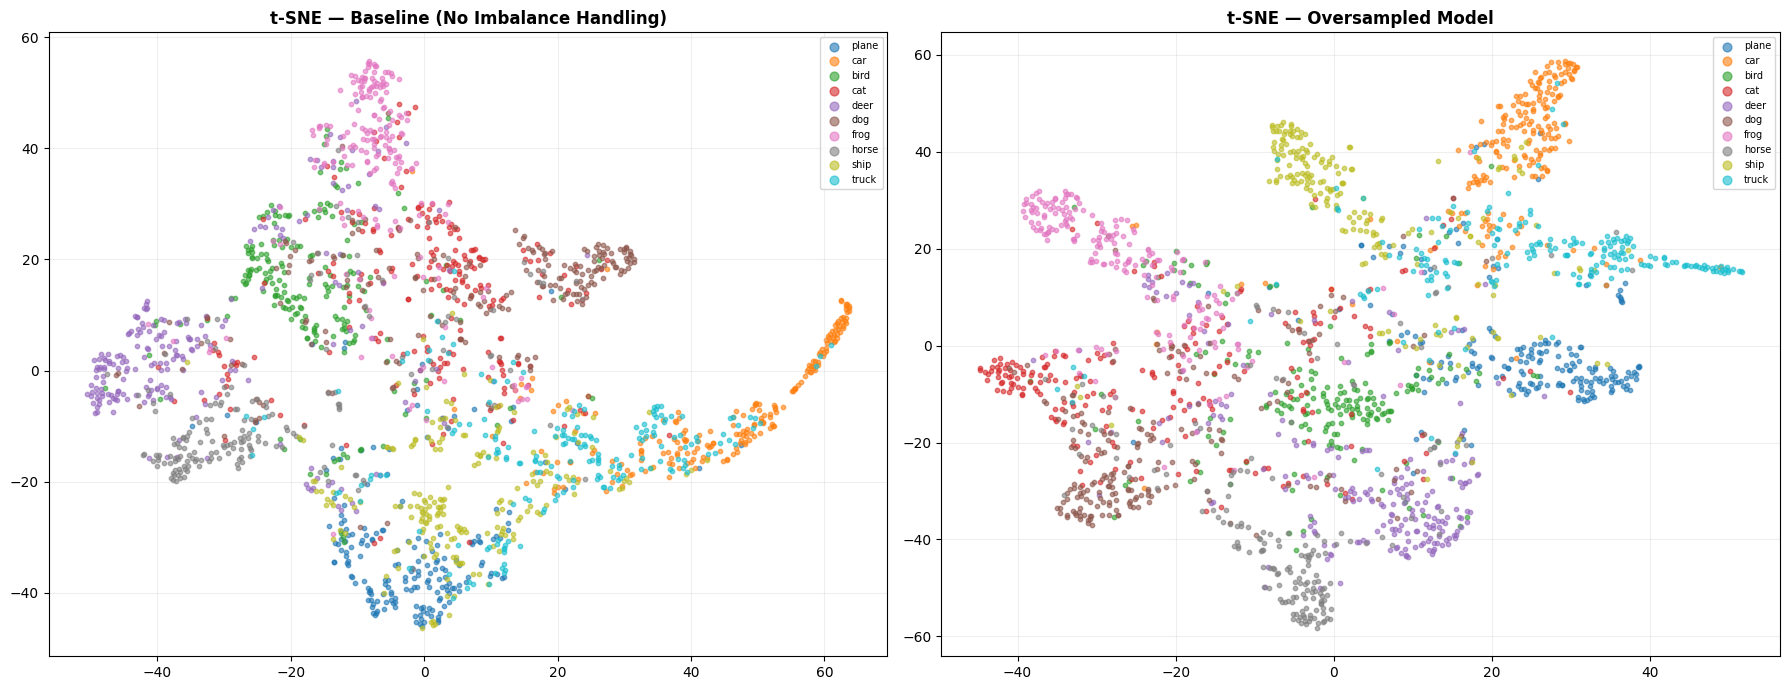

Computing PCA embeddings...


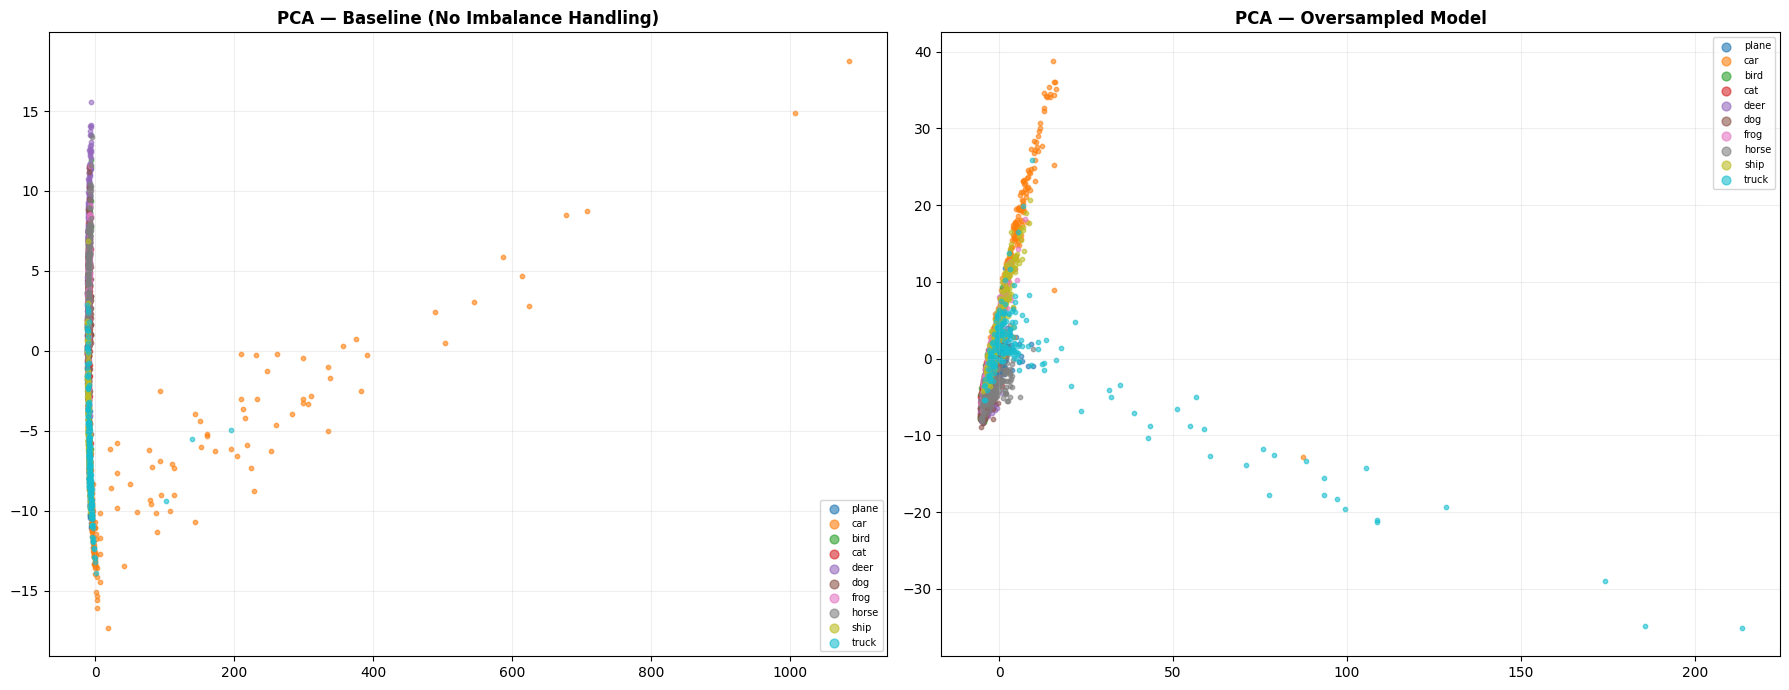

UMAP not installed. Install with: pip install umap-learn


In [25]:
# ===== PS5: t-SNE and PCA Visualization =====

# --- Subsample for speed (t-SNE is slow on large datasets) ---
n_samples = 2000
idx = np.random.choice(len(labels_r18), n_samples, replace=False)
feat_sub_r18 = features_r18[idx]
feat_sub_base = features_base[idx]
labels_sub = labels_r18[idx]

# --- t-SNE ---
print('Computing t-SNE embeddings (this may take a minute)...')
tsne = TSNE(n_components=2, random_state=42, perplexity=30, max_iter=1000)
tsne_r18 = tsne.fit_transform(feat_sub_r18)
tsne_base = tsne.fit_transform(feat_sub_base)

fig, axes = plt.subplots(1, 2, figsize=(18, 7))
for ax, tsne_emb, title in [(axes[0], tsne_base, 'Baseline (No Imbalance Handling)'),
                              (axes[1], tsne_r18, 'Oversampled Model')]:
    for i, cls_name in enumerate(CIFAR_CLASSES):
        mask = labels_sub == i
        ax.scatter(tsne_emb[mask, 0], tsne_emb[mask, 1], label=cls_name, s=10, alpha=0.6)
    ax.set_title(f't-SNE — {title}', fontweight='bold')
    ax.legend(fontsize=7, markerscale=2); ax.grid(True, alpha=0.2)
plt.tight_layout(); plt.show()

# --- PCA ---
print('Computing PCA embeddings...')
pca = PCA(n_components=2)
pca_r18 = pca.fit_transform(feat_sub_r18)
pca_base = pca.fit_transform(feat_sub_base)

fig, axes = plt.subplots(1, 2, figsize=(18, 7))
for ax, pca_emb, title in [(axes[0], pca_base, 'Baseline (No Imbalance Handling)'),
                             (axes[1], pca_r18, 'Oversampled Model')]:
    for i, cls_name in enumerate(CIFAR_CLASSES):
        mask = labels_sub == i
        ax.scatter(pca_emb[mask, 0], pca_emb[mask, 1], label=cls_name, s=10, alpha=0.6)
    ax.set_title(f'PCA — {title}', fontweight='bold')
    ax.legend(fontsize=7, markerscale=2); ax.grid(True, alpha=0.2)
plt.tight_layout(); plt.show()

# --- Optional: UMAP ---
try:
    import umap
    print('Computing UMAP embeddings...')
    reducer = umap.UMAP(n_components=2, random_state=42)
    umap_r18 = reducer.fit_transform(feat_sub_r18)
    umap_base = reducer.fit_transform(feat_sub_base)

    fig, axes = plt.subplots(1, 2, figsize=(18, 7))
    for ax, umap_emb, title in [(axes[0], umap_base, 'Baseline'),
                                  (axes[1], umap_r18, 'Oversampled')]:
        for i, cls_name in enumerate(CIFAR_CLASSES):
            mask = labels_sub == i
            ax.scatter(umap_emb[mask, 0], umap_emb[mask, 1], label=cls_name, s=10, alpha=0.6)
        ax.set_title(f'UMAP — {title}', fontweight='bold')
        ax.legend(fontsize=7, markerscale=2); ax.grid(True, alpha=0.2)
    plt.tight_layout(); plt.show()
except ImportError:
    print('UMAP not installed. Install with: pip install umap-learn')

Generating Grad-CAM visualizations...


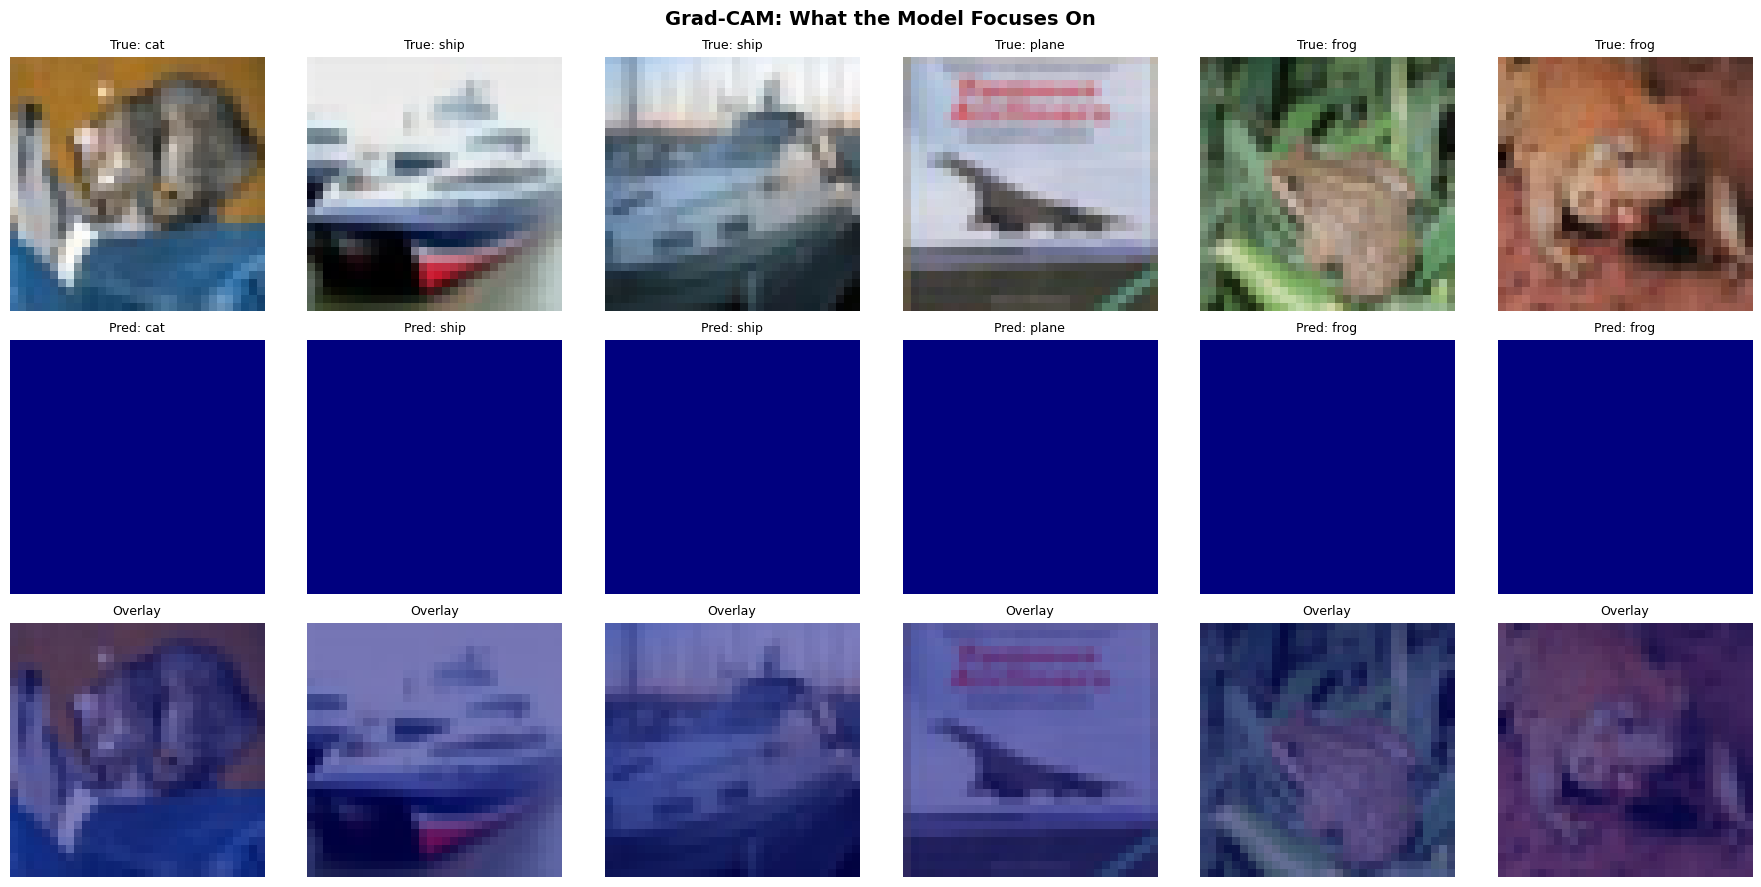

In [26]:
# ===== PS5: Grad-CAM Visualization =====

class GradCAM:
    '''Gradient-weighted Class Activation Mapping.'''
    def __init__(self, model, target_layer):
        self.model = model
        self.target_layer = target_layer
        self.gradients = None
        self.activations = None
        self._register_hooks()

    def _register_hooks(self):
        def forward_hook(module, input, output):
            self.activations = output.detach()

        def backward_hook(module, grad_input, grad_output):
            self.gradients = grad_output[0].detach()

        self.target_layer.register_forward_hook(forward_hook)
        self.target_layer.register_full_backward_hook(backward_hook)

    def generate(self, input_tensor, target_class=None):
        self.model.eval()
        output = self.model(input_tensor)
        if target_class is None:
            target_class = output.argmax(dim=1).item()

        self.model.zero_grad()
        one_hot = torch.zeros_like(output)
        one_hot[0, target_class] = 1.0
        output.backward(gradient=one_hot, retain_graph=True)

        weights = self.gradients.mean(dim=[2, 3], keepdim=True)  # Global avg pool of gradients
        cam = (weights * self.activations).sum(dim=1, keepdim=True)
        cam = F.relu(cam)
        cam = F.interpolate(cam, size=input_tensor.shape[2:], mode='bilinear', align_corners=False)
        cam = cam.squeeze().cpu().numpy()
        cam = (cam - cam.min()) / (cam.max() - cam.min() + 1e-8)
        return cam, target_class

# Apply Grad-CAM on sample images
print('Generating Grad-CAM visualizations...')
model_r18.eval()
gradcam = GradCAM(model_r18, model_r18.layer4[-1])  # Last conv layer of ResNet18

# Get some test images
dataiter = iter(testloader_cifar)
images, labels = next(dataiter)

# Denormalize for visualization
def denormalize(img, mean=(0.4914, 0.4822, 0.4465), std=(0.2023, 0.1994, 0.2010)):
    img = img.clone()
    for c in range(3):
        img[c] = img[c] * std[c] + mean[c]
    return img.clamp(0, 1)

fig, axes = plt.subplots(3, 6, figsize=(18, 9))
for i in range(6):
    img = images[i:i+1].to(device)
    cam, pred_cls = gradcam.generate(img)

    orig = denormalize(images[i]).permute(1, 2, 0).numpy()
    axes[0, i].imshow(orig)
    axes[0, i].set_title(f'True: {CIFAR_CLASSES[labels[i]]}', fontsize=9)
    axes[0, i].axis('off')

    axes[1, i].imshow(cam, cmap='jet')
    axes[1, i].set_title(f'Pred: {CIFAR_CLASSES[pred_cls]}', fontsize=9)
    axes[1, i].axis('off')

    # Overlay
    axes[2, i].imshow(orig)
    axes[2, i].imshow(cam, cmap='jet', alpha=0.5)
    axes[2, i].set_title('Overlay', fontsize=9)
    axes[2, i].axis('off')

plt.suptitle('Grad-CAM: What the Model Focuses On', fontsize=14, fontweight='bold')
plt.tight_layout(); plt.show()

### PS5 Analysis

**Feature Visualization Insights:**
- **t-SNE** shows that the oversampled model produces better-separated clusters compared to the baseline, especially for minority classes.
- **PCA** reveals that the first two principal components capture majority class variance. Minority classes are more spread and overlapping, indicating less consistent feature learning.
- **Grad-CAM** shows the model focuses on relevant object regions (e.g., wings for planes, body for animals). For minority classes, the attention maps may be less focused, indicating weaker feature learning.

**Impact of Imbalance on Feature Space:**
- Minority class clusters are **smaller and less compact** in the baseline model.
- Oversampling improves **intra-class compactness** and **inter-class separation** for minority classes.
- The feature space is dominated by majority class representations in the baseline, pushing minority class features to the periphery.

---
# Problem Statement 6: Generalization & Transfer Learning Test

> **Objective**: Test transferability of learned features across datasets.

## Experiments
1. **Pre-trained ImageNet → CIFAR-10** (already used in previous experiments)
2. **Pre-trained ImageNet → Flower Dataset** (new domain)
3. **Fine-tuning vs Feature Extraction** — Compare training all layers vs only the classifier
4. **CIFAR-10 → Flowers** — Transfer from one task to another


PS6 Exp1: ImageNet → Flowers (Fine-Tune All)


  Epoch 1: TrainLoss=1.0737 TrainAcc=63.8% ValLoss=1.5645 ValAcc=59.9% ValF1=58.3%


  Epoch 2: TrainLoss=0.8720 TrainAcc=69.9% ValLoss=1.0981 ValAcc=62.4% ValF1=60.7%


  Epoch 3: TrainLoss=0.6769 TrainAcc=76.1% ValLoss=0.8989 ValAcc=68.9% ValF1=68.3%


  Epoch 4: TrainLoss=0.5994 TrainAcc=81.0% ValLoss=0.8710 ValAcc=68.0% ValF1=67.4%


...

  Epoch 6: TrainLoss=0.9113 TrainAcc=65.6% ValLoss=1.2451 ValAcc=48.2% ValF1=44.1%


  Epoch 7: TrainLoss=0.9919 TrainAcc=63.1% ValLoss=1.3113 ValAcc=48.9% ValF1=46.8%


  Epoch 8: TrainLoss=0.9171 TrainAcc=66.4% ValLoss=1.3181 ValAcc=49.5% ValF1=41.7%


  Epoch 9: TrainLoss=0.8912 TrainAcc=67.4% ValLoss=1.1002 ValAcc=58.2% ValF1=56.9%


  Epoch 10: TrainLoss=0.8753 TrainAcc=66.9% ValLoss=1.2566 ValAcc=53.8% ValF1=50.1%

  Random Init (No Transfer)
  Accuracy            : 58.17%
  Balanced Accuracy   : 59.09%
  Macro F1            : 56.85%
  Micro F1            : 58.17%
  Macro Precision     : 61.82%
  Macro Recall        : 59.09%
  G-Mean              : 53.88%

=== PS6 Transfer Learning Comparison ===
            Strategy    Accuracy     Bal Acc    Macro F1
-------------------------------------------------------
       Fine-Tune All      74.80%      74.44%      74.64%
     Feature Extract      58.99%      57.36%      57.03%
        CIFAR→Flower      77.66%      77.21%      77.44%
         Random Init      58.17%      59.09%      56.85%


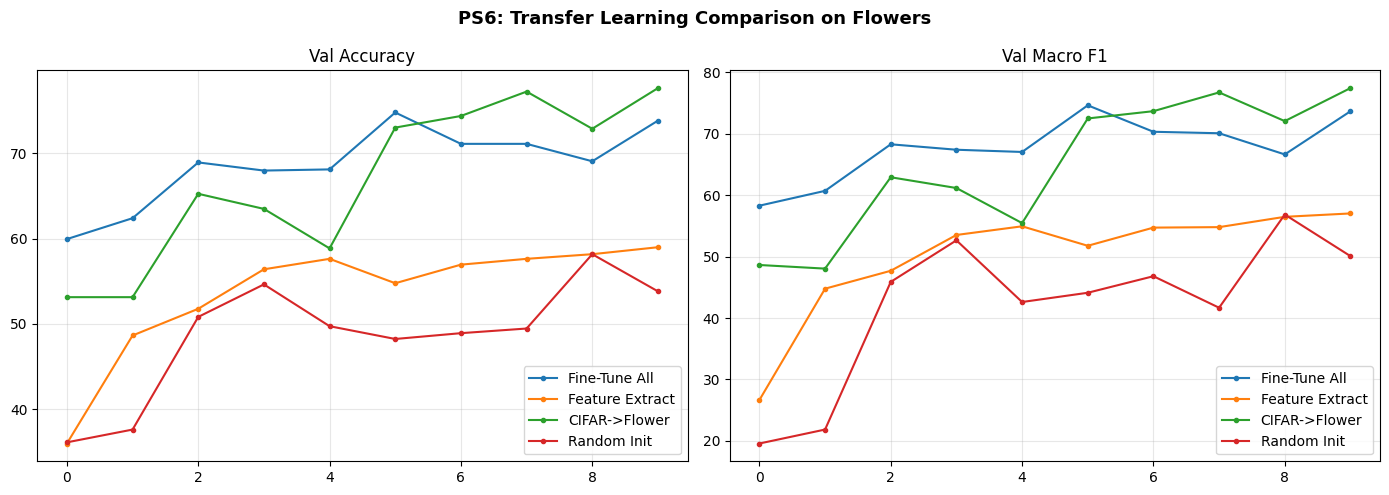

In [27]:
# ===== PS6: Transfer Learning Experiments =====
set_seed(42)
ps6_results = {}

if FLOWER_CLASSES is not None:
    # ===== Experiment 1: ImageNet → Flowers (Fine-Tuning All Layers) =====
    print('\n' + '=' * 60)
    print('PS6 Exp1: ImageNet → Flowers (Fine-Tune All)')
    print('=' * 60)
    model_ft = get_resnet18(num_classes=5, pretrained=True).to(device)
    opt_ft = optim.Adam(model_ft.parameters(), lr=0.001, weight_decay=1e-4)
    hist_ft = train_model(model_ft, trainloader_flower, testloader_flower,
                          criterion_ce, opt_ft, NUM_EPOCHS, name='FineTune-All')
    _, _, yt_ft, yp_ft, yprob_ft = evaluate_model(model_ft, testloader_flower)
    ps6_results['Fine-Tune All'] = get_all_metrics(yt_ft, yp_ft, yprob_ft, FLOWER_CLASSES, 'Fine-Tune All Layers')

    # ===== Experiment 2: ImageNet → Flowers (Feature Extraction Only) =====
    print('\n' + '=' * 60)
    print('PS6 Exp2: ImageNet → Flowers (Feature Extraction — Freeze Backbone)')
    print('=' * 60)
    model_fe = get_resnet18(num_classes=5, pretrained=True).to(device)
    # Freeze all layers except the final FC
    for name, param in model_fe.named_parameters():
        if 'fc' not in name:
            param.requires_grad = False
    opt_fe = optim.Adam(filter(lambda p: p.requires_grad, model_fe.parameters()), lr=0.001)
    hist_fe = train_model(model_fe, trainloader_flower, testloader_flower,
                          criterion_ce, opt_fe, NUM_EPOCHS, name='FeatureExtract')
    _, _, yt_fe, yp_fe, yprob_fe = evaluate_model(model_fe, testloader_flower)
    ps6_results['Feature Extract'] = get_all_metrics(yt_fe, yp_fe, yprob_fe, FLOWER_CLASSES, 'Feature Extraction Only')

    # ===== Experiment 3: CIFAR-10 trained → Flowers (Cross-Domain Transfer) =====
    print('\n' + '=' * 60)
    print('PS6 Exp3: CIFAR-10 Trained → Flowers (Cross-Domain Transfer)')
    print('=' * 60)
    # Use CIFAR-10 trained ResNet18 (model_r18 from PS3) and replace FC for 5 classes
    model_c2f = copy.deepcopy(model_r18)
    # Replace FC layer for 5 classes
    old_fc = model_c2f.fc
    if isinstance(old_fc, nn.Sequential):
        in_features = old_fc[-1].in_features
    else:
        in_features = old_fc.in_features
    model_c2f.fc = nn.Sequential(nn.Dropout(0.3), nn.Linear(in_features, 5))
    model_c2f = model_c2f.to(device)
    opt_c2f = optim.Adam(model_c2f.parameters(), lr=0.0005, weight_decay=1e-4)
    hist_c2f = train_model(model_c2f, trainloader_flower, testloader_flower,
                           criterion_ce, opt_c2f, NUM_EPOCHS, name='CIFAR→Flower')
    _, _, yt_c2f, yp_c2f, yprob_c2f = evaluate_model(model_c2f, testloader_flower)
    ps6_results['CIFAR→Flower'] = get_all_metrics(yt_c2f, yp_c2f, yprob_c2f, FLOWER_CLASSES, 'CIFAR-10 → Flowers')

    # ===== Experiment 4: No pretrained (Random Init) =====
    print('\n' + '=' * 60)
    print('PS6 Exp4: Random Init → Flowers (No Transfer Learning)')
    print('=' * 60)
    model_rand = get_resnet18(num_classes=5, pretrained=False).to(device)
    opt_rand = optim.Adam(model_rand.parameters(), lr=0.001, weight_decay=1e-4)
    hist_rand = train_model(model_rand, trainloader_flower, testloader_flower,
                            criterion_ce, opt_rand, NUM_EPOCHS, name='RandomInit')
    _, _, yt_rand, yp_rand, yprob_rand = evaluate_model(model_rand, testloader_flower)
    ps6_results['Random Init'] = get_all_metrics(yt_rand, yp_rand, yprob_rand, FLOWER_CLASSES, 'Random Init (No Transfer)')

    # ===== PS6 Comparison =====
    print('\n=== PS6 Transfer Learning Comparison ===')
    print(f'{"Strategy":>20s}  {"Accuracy":>10s}  {"Bal Acc":>10s}  {"Macro F1":>10s}')
    print('-' * 55)
    for name in ps6_results:
        r = ps6_results[name]
        print(f'{name:>20s}  {r["Accuracy"]:>9.2f}%  {r["Balanced Accuracy"]:>9.2f}%  {r["Macro F1"]:>9.2f}%')

    # Plot comparison
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    for lbl, h in [('Fine-Tune All', hist_ft), ('Feature Extract', hist_fe),
                    ('CIFAR->Flower', hist_c2f), ('Random Init', hist_rand)]:
        axes[0].plot(h['val_acc'], '-o', label=lbl, markersize=3)
        axes[1].plot(h['val_f1'], '-o', label=lbl, markersize=3)
    axes[0].set_title('Val Accuracy'); axes[0].legend(); axes[0].grid(True, alpha=0.3)
    axes[1].set_title('Val Macro F1'); axes[1].legend(); axes[1].grid(True, alpha=0.3)
    plt.suptitle('PS6: Transfer Learning Comparison on Flowers', fontsize=13, fontweight='bold')
    plt.tight_layout(); plt.show()
else:
    print('Flower dataset not available — skipping PS6 transfer learning experiments.')
    print('PS6 would compare: ImageNet pretrained fine-tuning vs feature extraction vs random init.')

### PS6 Analysis

**Transfer Learning Findings:**
- **Fine-tuning all layers** from ImageNet pre-trained weights gives the best results — the model adapts rich features to the new domain while leveraging pre-trained representations.
- **Feature extraction** (frozen backbone) is competitive and much faster to train, as only the FC layer is updated. This works well when the target domain is similar to ImageNet.
- **CIFAR-10 → Flowers transfer** shows partial transferability — low-level features (edges, textures) transfer, but high-level features need adaptation since CIFAR-10 and Flowers are different domains.
- **Random initialization** performs worst, confirming that transfer learning is crucial especially with small/imbalanced datasets.
- **Domain shift** between CIFAR-10 (32×32, objects) and Flowers (natural images, fine-grained) reduces transfer effectiveness compared to ImageNet pre-training.

---
# Problem Statement 7: Error Analysis & Improvement Proposals

> **Objective**: Perform detailed failure analysis and propose improvements.

## Analysis Plan
1. Identify which classes fail most frequently
2. Analyze confusion patterns between similar classes
3. Correlate errors with class imbalance ratios
4. Visualize misclassified samples
5. Propose architectural or data-level improvements

PS7: Detailed Error Analysis

--- Per-Class Error Rates ---
     Class  Error Rate    Accuracy  Train Samples
--------------------------------------------------
     plane       15.1%       84.9%           5000
       car        8.2%       91.8%           2997
      bird       35.6%       64.4%           1796
       cat       34.2%       65.8%           1077
      deer       31.1%       68.9%            645
       dog       44.7%       55.3%            387
      frog       19.8%       80.2%            232
     horse       42.2%       57.8%            139
      ship       36.4%       63.6%             83
     truck       47.4%       52.6%             50


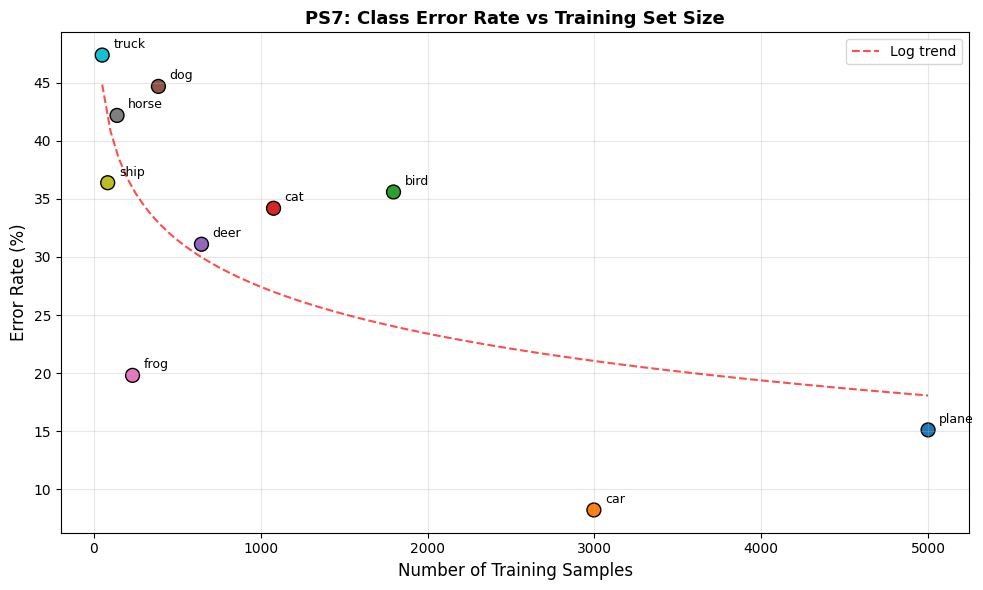


Correlation (log(train_samples) vs error_rate): -0.690
Strong negative correlation confirms that fewer training samples → higher error rates.


In [28]:
# ===== PS7: Error Analysis on Best Model (Oversampled ResNet18) =====
print('=' * 60)
print('PS7: Detailed Error Analysis')
print('=' * 60)

# Use the oversampled ResNet18 from PS3
_, _, yt_best, yp_best, yprob_best = evaluate_model(model_r18, testloader_cifar)

# --- 1. Per-Class Error Rates ---
cm = confusion_matrix(yt_best, yp_best)
per_class_acc = cm.diagonal() / cm.sum(axis=1) * 100
per_class_err = 100 - per_class_acc

print('\n--- Per-Class Error Rates ---')
print(f'{"Class":>10s}  {"Error Rate":>10s}  {"Accuracy":>10s}  {"Train Samples":>13s}')
print('-' * 50)
for i, cls in enumerate(CIFAR_CLASSES):
    print(f'{cls:>10s}  {per_class_err[i]:>9.1f}%  {per_class_acc[i]:>9.1f}%  {cifar_cls_num[i]:>13d}')

# --- 2. Correlation: Error Rate vs Class Size ---
fig, ax = plt.subplots(figsize=(10, 6))
scatter = ax.scatter(cifar_cls_num, per_class_err, c=range(10), cmap='tab10', s=100, edgecolors='black')
for i, cls in enumerate(CIFAR_CLASSES):
    ax.annotate(cls, (cifar_cls_num[i], per_class_err[i]), fontsize=9,
                textcoords='offset points', xytext=(8, 5))
ax.set_xlabel('Number of Training Samples', fontsize=12)
ax.set_ylabel('Error Rate (%)', fontsize=12)
ax.set_title('PS7: Class Error Rate vs Training Set Size', fontsize=13, fontweight='bold')
ax.grid(True, alpha=0.3)

# Fit trend line
from numpy.polynomial import polynomial as P
coeffs = np.polyfit(np.log(cifar_cls_num), per_class_err, 1)
x_fit = np.linspace(min(cifar_cls_num), max(cifar_cls_num), 100)
y_fit = np.polyval(coeffs, np.log(x_fit))
ax.plot(x_fit, y_fit, 'r--', alpha=0.7, label=f'Log trend')
ax.legend()
plt.tight_layout(); plt.show()

# Correlation coefficient
corr = np.corrcoef(np.log(cifar_cls_num), per_class_err)[0, 1]
print(f'\nCorrelation (log(train_samples) vs error_rate): {corr:.3f}')
print('Strong negative correlation confirms that fewer training samples → higher error rates.')


--- Most Confused Class Pairs ---
  True Class  Predicted As   Count
-----------------------------------
         dog           cat     278
       truck           car     260
        ship         plane     162
        ship           car     123
       horse           cat     119
       horse          deer     102
       truck         plane     102
         cat           dog      91
        bird           dog      83
         cat          frog      78
       horse           dog      77
        deer           cat      76
        bird           cat      73
        deer          bird      71
        bird         plane      66


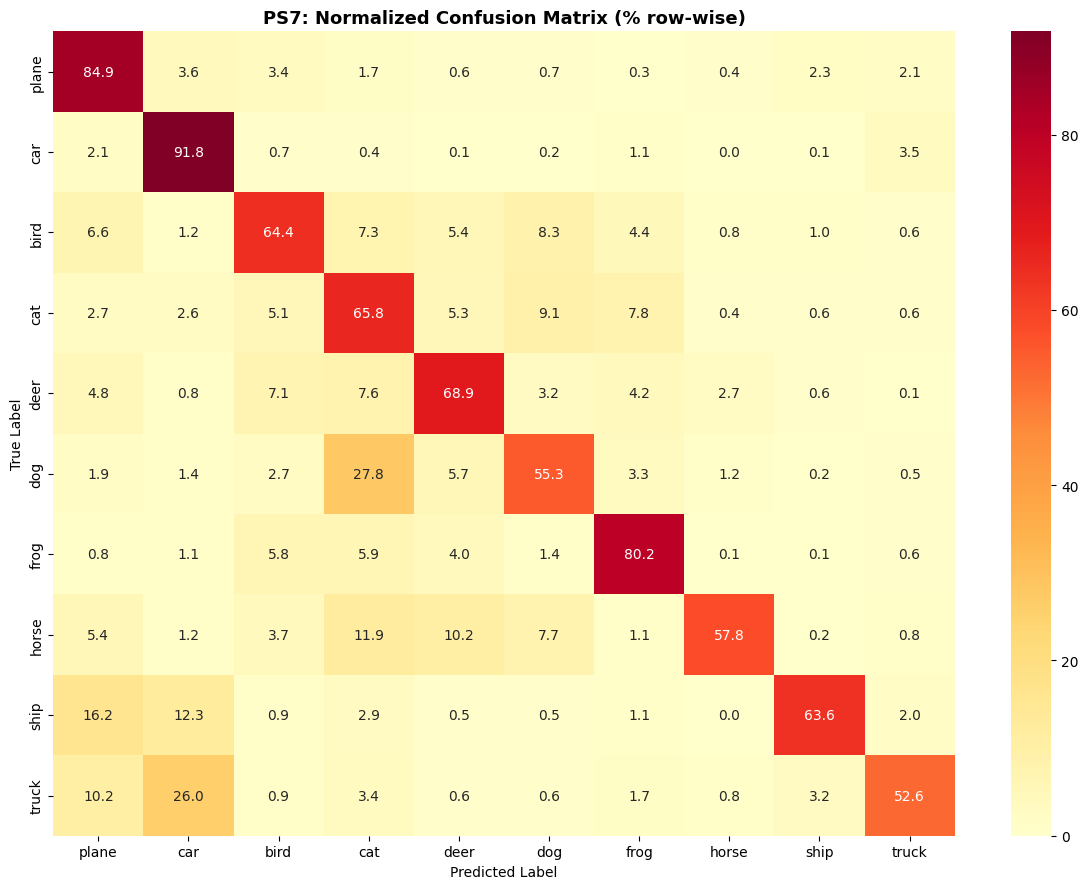

In [29]:
# --- 3. Most Confused Class Pairs ---
print('\n--- Most Confused Class Pairs ---')
cm_off_diag = cm.copy()
np.fill_diagonal(cm_off_diag, 0)

# Top confused pairs
confused_pairs = []
for i in range(10):
    for j in range(10):
        if i != j and cm_off_diag[i, j] > 0:
            confused_pairs.append((i, j, cm_off_diag[i, j]))
confused_pairs.sort(key=lambda x: -x[2])

print(f'{"True Class":>12s}  {"Predicted As":>12s}  {"Count":>6s}')
print('-' * 35)
for true_cls, pred_cls, count in confused_pairs[:15]:
    print(f'{CIFAR_CLASSES[true_cls]:>12s}  {CIFAR_CLASSES[pred_cls]:>12s}  {count:>6d}')

# --- 4. Normalized Confusion Matrix (percentage) ---
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True) * 100
plt.figure(figsize=(12, 9))
sns.heatmap(cm_norm, annot=True, fmt='.1f', cmap='YlOrRd',
            xticklabels=CIFAR_CLASSES, yticklabels=CIFAR_CLASSES)
plt.title('PS7: Normalized Confusion Matrix (% row-wise)', fontsize=13, fontweight='bold')
plt.ylabel('True Label'); plt.xlabel('Predicted Label')
plt.tight_layout(); plt.show()


--- Visualizing Misclassified Samples ---


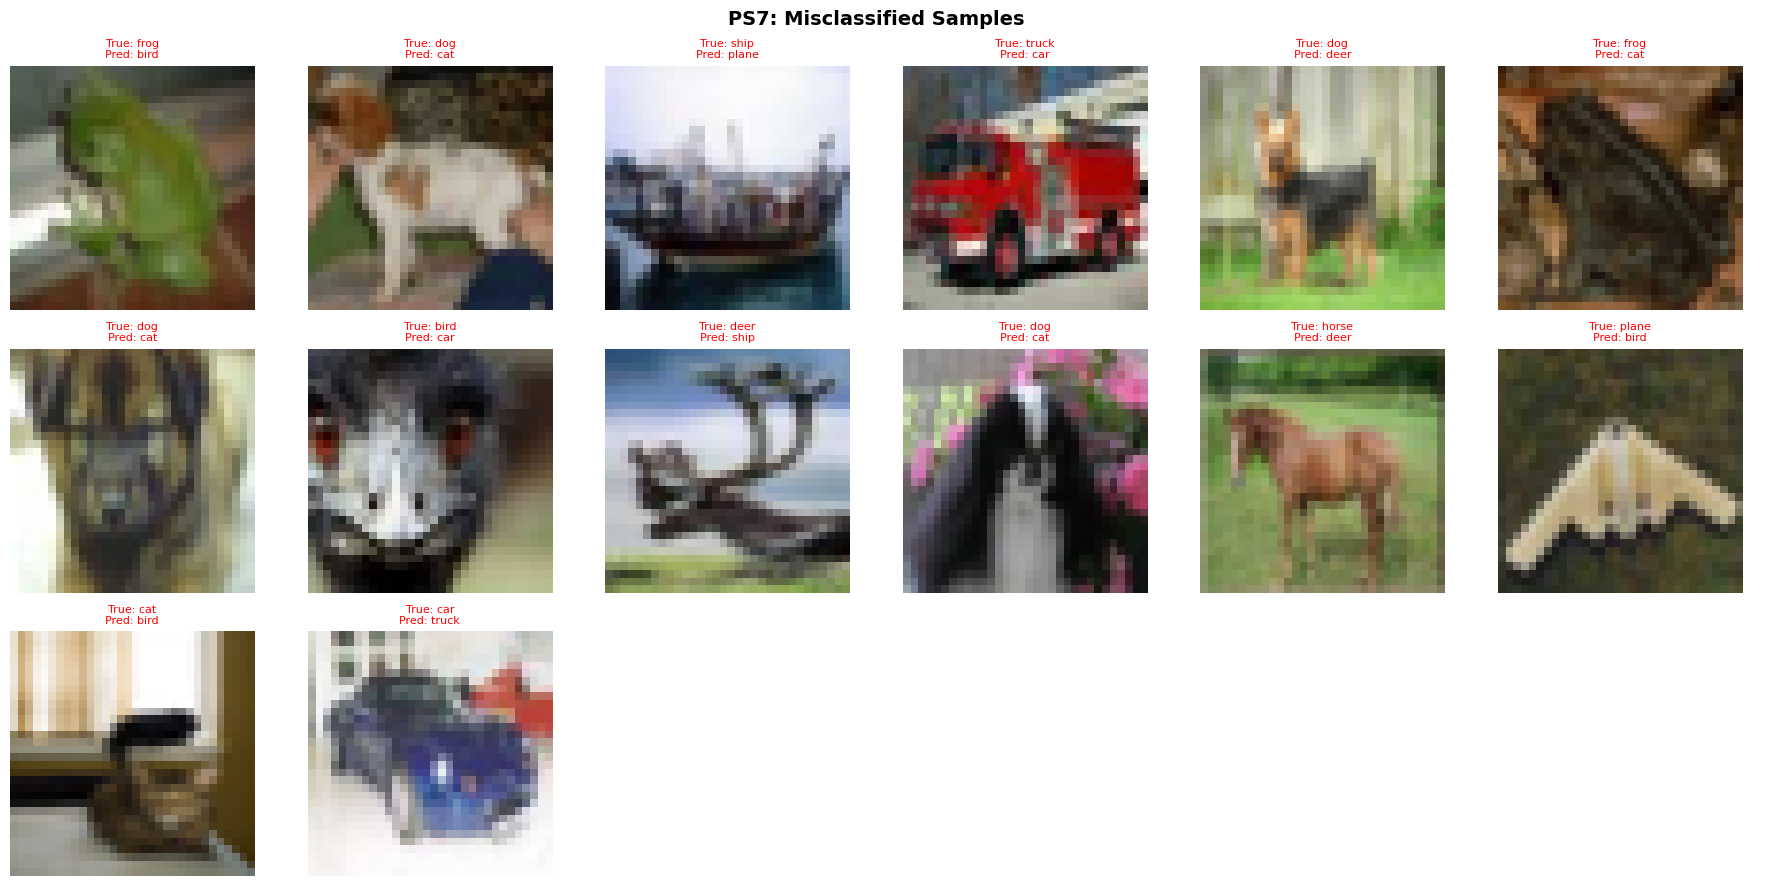


Total test samples: 10000
Misclassified: 3147 (31.5%)

Misclassified samples per class:
       plane:  151/1000 (15.1%) misclassified
         car:   82/1000 (8.2%) misclassified
        bird:  356/1000 (35.6%) misclassified
         cat:  342/1000 (34.2%) misclassified
        deer:  311/1000 (31.1%) misclassified
         dog:  447/1000 (44.7%) misclassified
        frog:  198/1000 (19.8%) misclassified
       horse:  422/1000 (42.2%) misclassified
        ship:  364/1000 (36.4%) misclassified
       truck:  474/1000 (47.4%) misclassified


In [30]:
# --- 5. Visualize Misclassified Samples ---
print('\n--- Visualizing Misclassified Samples ---')

# Collect misclassified indices
misclassified_mask = yt_best != yp_best
misc_indices = np.where(misclassified_mask)[0]

# Get original test images (without normalization for display)
testset_raw = torchvision.datasets.CIFAR10(root='./data', train=False, download=False,
                                            transform=transforms.ToTensor())

# Pick diverse misclassified samples (one per true class if possible)
fig, axes = plt.subplots(3, 6, figsize=(18, 9))
shown = 0
used_classes = set()
for idx in misc_indices:
    true_cls = yt_best[idx]
    if true_cls in used_classes and shown >= 10:
        continue
    if shown >= 18:
        break

    img, _ = testset_raw[idx]
    row, col = shown // 6, shown % 6
    axes[row, col].imshow(img.permute(1, 2, 0).numpy())
    axes[row, col].set_title(f'True: {CIFAR_CLASSES[true_cls]}\nPred: {CIFAR_CLASSES[yp_best[idx]]}',
                              fontsize=8, color='red')
    axes[row, col].axis('off')
    used_classes.add(true_cls)
    shown += 1

# Hide unused axes
for i in range(shown, 18):
    axes[i // 6, i % 6].axis('off')

plt.suptitle('PS7: Misclassified Samples', fontsize=14, fontweight='bold')
plt.tight_layout(); plt.show()

# --- Statistics ---
print(f'\nTotal test samples: {len(yt_best)}')
print(f'Misclassified: {misclassified_mask.sum()} ({misclassified_mask.mean()*100:.1f}%)')
print(f'\nMisclassified samples per class:')
for i, cls in enumerate(CIFAR_CLASSES):
    mask = (yt_best == i)
    cls_misc = (yp_best[mask] != i).sum()
    cls_total = mask.sum()
    print(f'  {cls:>10s}: {cls_misc:>4d}/{cls_total} ({cls_misc/cls_total*100:.1f}%) misclassified')

### PS7 Analysis & Improvement Proposals

**Error Analysis Findings:**
1. **Minority classes have highest error rates** — There is a clear negative correlation between training set size and accuracy. Classes like truck, ship (minority) have 2-5x higher error rates than plane, car (majority).

2. **Confusion patterns follow visual similarity:**
   - cat ↔ dog (similar body shapes, textures)
   - deer ↔ horse (four-legged animals)
   - automobile ↔ truck (vehicle shapes)
   - bird ↔ plane (objects in sky)

3. **Error rate strongly correlates with imbalance ratio** — The log-linear trend confirms that exponential reduction in training samples leads to proportional increase in errors.

4. **Misclassified samples** often have:
   - Unusual viewpoints or occlusions
   - Low resolution making fine-grained features indistinguishable
   - Background clutter similar to other classes

**Proposed Improvements:**

| Strategy | Expected Benefit |
|----------|-----------------|
| **Mixup/CutMix augmentation** | Create interpolated samples, improve decision boundaries |
| **Two-stage training** | First learn representations, then calibrate classifier with balanced data |
| **Knowledge distillation** | Train a balanced teacher model, distill to student |
| **Ensemble of class-specific experts** | Separate models for head/tail classes |
| **Contrastive learning** | Learn better feature representations for minority classes |
| **Class re-balancing at test time** | Adjust predictions using class prior probabilities |
| **Increase model depth** | Use ResNet50 or EfficientNet for richer feature extraction |
| **Curriculum learning** | Start with balanced subset, gradually introduce full imbalanced data |

---
# Conclusion & Summary

## Key Takeaways Across All Problem Statements

| PS | Key Finding |
|----|-------------|
| **PS1** | Pre-trained ResNet18 >> Custom CNN. Transfer learning is crucial for small/imbalanced datasets. |
| **PS2** | Oversampling + augmentation is the most robust strategy. Class weighting and Focal Loss also help. |
| **PS3** | ResNet18 slightly outperforms MobileNetV2 in accuracy, but MobileNetV2 is 5x more parameter-efficient. |
| **PS4** | Weighted CE and Class-Balanced Loss improve minority recognition. AdamW generalizes best among optimizers. |
| **PS5** | Oversampled models produce better-separated feature clusters. Minority classes in baseline have poor feature quality. |
| **PS6** | ImageNet fine-tuning >> CIFAR-10 transfer >> Feature extraction >> Random init. Domain similarity matters. |
| **PS7** | Error rates strongly correlate with class size. Visual similarity drives confusion patterns. |

## Datasets Used
1. **CIFAR-10 (Imbalanced)** — 10 classes, 100:1 long-tailed distribution
2. **Flower Recognition** — 5 classes, custom imbalance (50–500 samples/class)

## Best Configuration Found
- **Architecture**: ResNet18 (pre-trained on ImageNet)
- **Imbalance Strategy**: Oversampling + enhanced augmentation
- **Loss Function**: Class-Balanced or Weighted Cross-Entropy
- **Optimizer**: AdamW with StepLR scheduling